## Testing gradient with numpy backend, independent of mesh

In [1]:
from QSER.Operators import Gradient
import numpy as np

# Create 2D data (NO mesh!)
nx, ny = 100, 100
x = np.linspace(0, 2*np.pi, nx)
y = np.linspace(0, 2*np.pi, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing='ij')

# Test function: f(x,y) = sin(x)*cos(y)
field = np.sin(X) * np.cos(Y)
analytical_x = np.cos(X) * np.cos(Y)
analytical_y = -np.sin(X) * np.sin(Y)

# Independent gradient operator
grad = Gradient(backend='numpy')
result = grad.compute(field, dx=dx, dy=dy, method='5point')

# Extract components
grad_x = result[:, :, 0]
grad_y = result[:, :, 1]

# Check errors
interior = slice(2, -2), slice(2, -2)
error_x = np.max(np.abs(grad_x[interior] - analytical_x[interior]))
error_y = np.max(np.abs(grad_y[interior] - analytical_y[interior]))

print(f"Gradient error (x): {error_x:.6e}")
print(f"Gradient error (y): {error_y:.6e}")

Gradient error (x): 5.400224e-07
Gradient error (y): 5.404305e-07


## plotting results

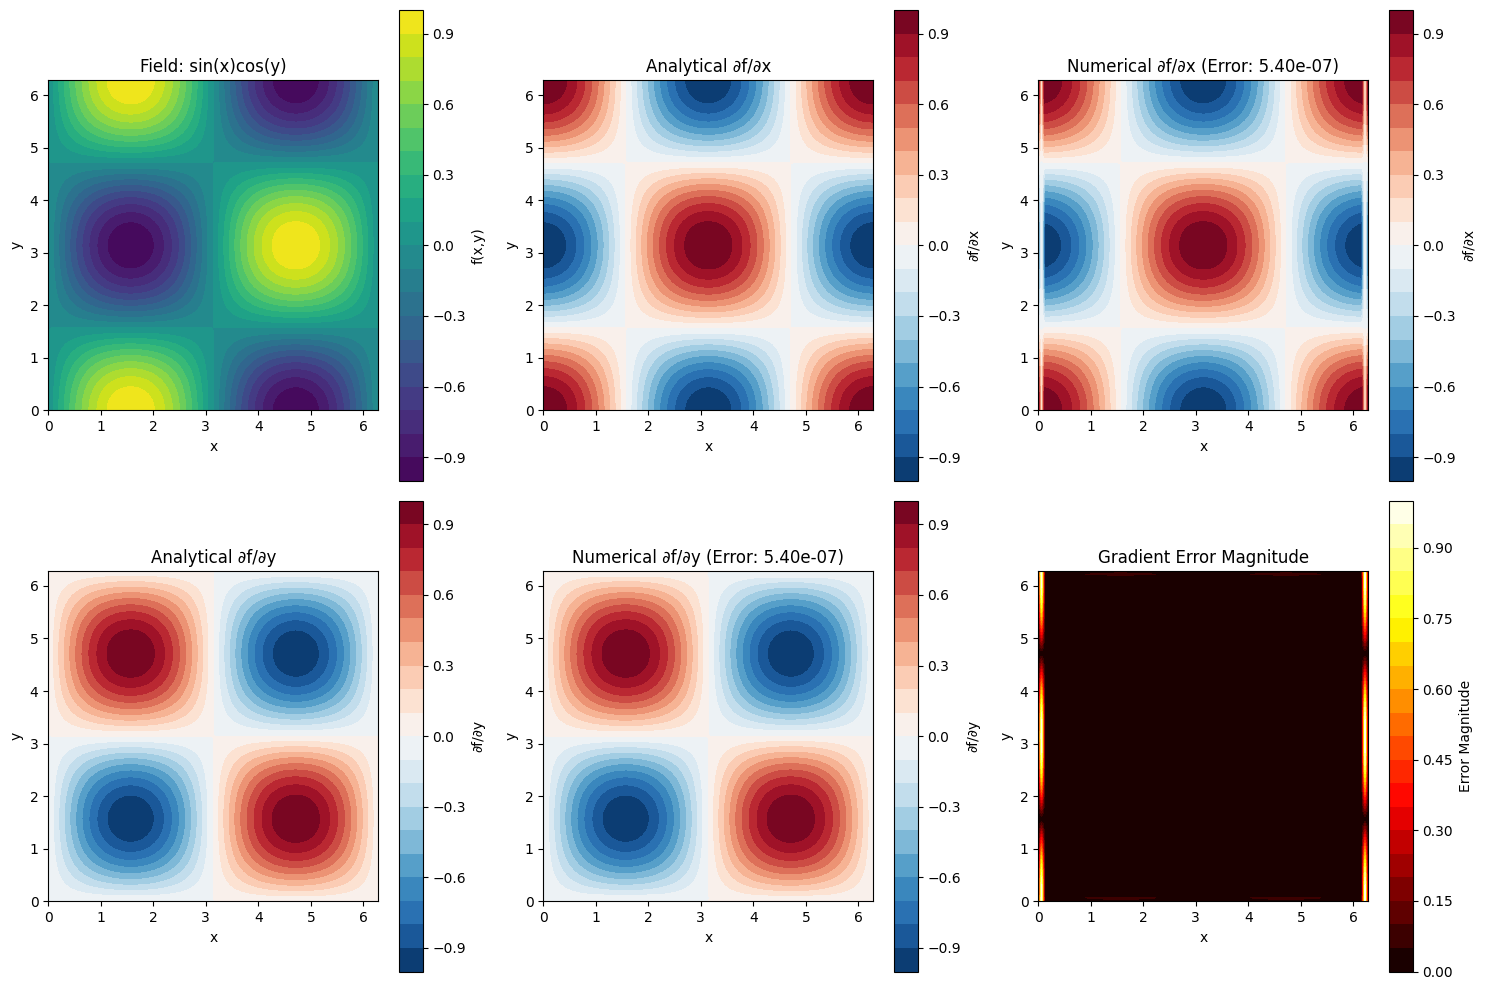

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Field
im0 = axes[0, 0].contourf(X, Y, field, levels=20, cmap='viridis')
plt.colorbar(im0, ax=axes[0, 0], label='f(x,y)')
axes[0, 0].set_title('Field: sin(x)cos(y)')
axes[0, 0].set_xlabel('x'); axes[0, 0].set_ylabel('y')
axes[0, 0].set_aspect('equal')

# Analytical ∂f/∂x
im1 = axes[0, 1].contourf(X, Y, analytical_x, levels=20, cmap='RdBu_r')
plt.colorbar(im1, ax=axes[0, 1], label='∂f/∂x')
axes[0, 1].set_title('Analytical ∂f/∂x')
axes[0, 1].set_xlabel('x'); axes[0, 1].set_ylabel('y')
axes[0, 1].set_aspect('equal')

# Numerical ∂f/∂x
im2 = axes[0, 2].contourf(X, Y, grad_x, levels=20, cmap='RdBu_r')
plt.colorbar(im2, ax=axes[0, 2], label='∂f/∂x')
axes[0, 2].set_title(f'Numerical ∂f/∂x (Error: {error_x:.2e})')
axes[0, 2].set_xlabel('x'); axes[0, 2].set_ylabel('y')
axes[0, 2].set_aspect('equal')

# Analytical ∂f/∂y
im3 = axes[1, 0].contourf(X, Y, analytical_y, levels=20, cmap='RdBu_r')
plt.colorbar(im3, ax=axes[1, 0], label='∂f/∂y')
axes[1, 0].set_title('Analytical ∂f/∂y')
axes[1, 0].set_xlabel('x'); axes[1, 0].set_ylabel('y')
axes[1, 0].set_aspect('equal')

# Numerical ∂f/∂y
im4 = axes[1, 1].contourf(X, Y, grad_y, levels=20, cmap='RdBu_r')
plt.colorbar(im4, ax=axes[1, 1], label='∂f/∂y')
axes[1, 1].set_title(f'Numerical ∂f/∂y (Error: {error_y:.2e})')
axes[1, 1].set_xlabel('x'); axes[1, 1].set_ylabel('y')
axes[1, 1].set_aspect('equal')

# Error magnitude
error_mag = np.sqrt((grad_x - analytical_x)**2 + (grad_y - analytical_y)**2)
im5 = axes[1, 2].contourf(X, Y, error_mag, levels=20, cmap='hot')
plt.colorbar(im5, ax=axes[1, 2], label='Error Magnitude')
axes[1, 2].set_title('Gradient Error Magnitude')
axes[1, 2].set_xlabel('x'); axes[1, 2].set_ylabel('y')
axes[1, 2].set_aspect('equal')

plt.tight_layout()
plt.show()

## Gradient test with different backends and methods

In [3]:
from QSER.Operators import Gradient
import numpy as np
import time

# ============================================================
# 2D GRADIENT TEST - ALL BACKENDS & METHODS
# ============================================================

# Create 2D data
nx, ny = 100, 100
x = np.linspace(0, 2*np.pi, nx)
y = np.linspace(0, 2*np.pi, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing='ij')

# Test function: f(x,y) = sin(x)*cos(y)
field = np.sin(X) * np.cos(Y)
analytical_x = np.cos(X) * np.cos(Y)
analytical_y = -np.sin(X) * np.sin(Y)

# Backends and methods
backends = ['numpy', 'torch', 'jax']
methods = ['5point', 'least_squares']

print("=" * 70)
print("2D GRADIENT TEST - ALL BACKENDS & METHODS")
print("=" * 70)
print(f"\nGrid: {nx} x {ny} = {nx*ny} points")
print(f"dx = {dx:.4f}, dy = {dy:.4f}")
print(f"Function: f(x,y) = sin(x)*cos(y)")

results = {}

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    results[backend] = {}
    
    for method in methods:
        print(f"  Method: {method}")
        results[backend][method] = {}
        
        try:
            grad = Gradient(backend=backend)
            
            start = time.time()
            result = grad.compute(field, dx=dx, dy=dy, method=method)
            elapsed = time.time() - start
            
            # Convert to numpy
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            grad_x = result[:, :, 0]
            grad_y = result[:, :, 1]
            
            interior = slice(2, -2), slice(2, -2)
            error_x = np.max(np.abs(grad_x[interior] - analytical_x[interior]))
            error_y = np.max(np.abs(grad_y[interior] - analytical_y[interior]))
            error_max = max(error_x, error_y)
            
            results[backend][method] = {
                'error_x': error_x,
                'error_y': error_y,
                'error_max': error_max,
                'time': elapsed
            }
            
            print(f"    ∂x error: {error_x:.6e}")
            print(f"    ∂y error: {error_y:.6e}")
            print(f"    Max error: {error_max:.6e}")
            print(f"    Time: {elapsed:.4f}s")
            
        except Exception as e:
            print(f"    FAILED: {str(e)[:60]}")
            results[backend][method] = None

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(f"{'Backend':<10} {'Method':<14} {'∂x Error':<14} {'∂y Error':<14} {'Time (s)':<10}")
print("-" * 70)

for backend in backends:
    for method in methods:
        if results[backend][method] is not None:
            r = results[backend][method]
            print(f"{backend:<10} {method:<14} {r['error_x']:.6e} {r['error_y']:.6e} {r['time']:.4f}")
        else:
            print(f"{backend:<10} {method:<14} {'FAILED':<14} {'FAILED':<14} {'FAILED':<10}")

print("\n" + "=" * 70)
print("TEST COMPLETE")
print("=" * 70)

2D GRADIENT TEST - ALL BACKENDS & METHODS

Grid: 100 x 100 = 10000 points
dx = 0.0635, dy = 0.0635
Function: f(x,y) = sin(x)*cos(y)

--- Backend: numpy ---
  Method: 5point
    ∂x error: 5.400224e-07
    ∂y error: 5.404305e-07
    Max error: 5.404305e-07
    Time: 0.0003s
  Method: least_squares
    ∂x error: 6.705223e-04
    ∂y error: 6.710290e-04
    Max error: 6.710290e-04
    Time: 0.0742s

--- Backend: torch ---
  Method: 5point
    ∂x error: 5.400224e-07
    ∂y error: 5.404305e-07
    Max error: 5.404305e-07
    Time: 0.0029s
  Method: least_squares
    ∂x error: 6.705223e-04
    ∂y error: 6.710290e-04
    Max error: 6.710290e-04
    Time: 0.2528s

--- Backend: jax ---
  Method: 5point
    ∂x error: 1.061971e-06
    ∂y error: 1.198191e-06
    Max error: 1.198191e-06
    Time: 0.5053s
  Method: least_squares
    ∂x error: 6.705533e-04
    ∂y error: 6.710703e-04
    Max error: 6.710703e-04
    Time: 6.6481s

SUMMARY TABLE
Backend    Method         ∂x Error       ∂y Error       Time

### Testing Laplacian 2D Quantum harmonic oscillator

In [4]:
from QSER.Operators import Gradient, Laplacian
import numpy as np
import time

# ============================================================
# 2D QUANTUM HARMONIC OSCILLATOR TEST
# ============================================================

# Create 2D data (Gaussian wavefunction)
nx, ny = 100, 100
x = np.linspace(-5, 5, nx)
y = np.linspace(-5, 5, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing='ij')

# Ground state wavefunction: ψ(x,y) = exp(-(x² + y²)/2)
psi = np.exp(-(X**2 + Y**2) / 2)

# Analytical derivatives
psi_x_analytical = -X * psi
psi_y_analytical = -Y * psi
psi_laplacian_analytical = (X**2 + Y**2 - 2) * psi

# Backends and methods
backends = ['numpy', 'torch', 'jax']
methods = ['5point', 'least_squares']

print("=" * 70)
print("2D QUANTUM HARMONIC OSCILLATOR")
print("ψ(x,y) = exp(-(x² + y²)/2)")
print("=" * 70)
print(f"\nGrid: {nx} x {ny} = {nx*ny} points")
print(f"Domain: x ∈ [-5, 5], y ∈ [-5, 5]")
print(f"dx = {dx:.4f}, dy = {dy:.4f}")

results = {'gradient': {}, 'laplacian': {}}

# ============================================================
# GRADIENT TEST
# ============================================================
print("\n" + "-" * 70)
print("GRADIENT TEST")
print("-" * 70)

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    results['gradient'][backend] = {}
    grad = Gradient(backend=backend)
    
    for method in methods:
        print(f"  Method: {method}")
        results['gradient'][backend][method] = {}
        
        try:
            start = time.time()
            result = grad.compute(psi, dx=dx, dy=dy, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            grad_x = result[:, :, 0]
            grad_y = result[:, :, 1]
            
            interior = slice(2, -2), slice(2, -2)
            error_x = np.max(np.abs(grad_x[interior] - psi_x_analytical[interior]))
            error_y = np.max(np.abs(grad_y[interior] - psi_y_analytical[interior]))
            error_max = max(error_x, error_y)
            
            results['gradient'][backend][method] = {
                'error_x': error_x,
                'error_y': error_y,
                'error_max': error_max,
                'time': elapsed
            }
            
            print(f"    ∂x error: {error_x:.6e}")
            print(f"    ∂y error: {error_y:.6e}")
            print(f"    Max error: {error_max:.6e}")
            print(f"    Time: {elapsed:.4f}s")
            
        except Exception as e:
            print(f"    FAILED: {str(e)[:60]}")
            results['gradient'][backend][method] = None

# ============================================================
# LAPLACIAN TEST
# ============================================================
print("\n" + "-" * 70)
print("LAPLACIAN TEST")
print("-" * 70)

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    results['laplacian'][backend] = {}
    lap = Laplacian(backend=backend)
    
    for method in methods:
        print(f"  Method: {method}")
        results['laplacian'][backend][method] = {}
        
        try:
            start = time.time()
            result = lap.compute(psi, dx=dx, dy=dy, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result[interior] - psi_laplacian_analytical[interior]))
            
            results['laplacian'][backend][method] = {
                'error': error,
                'time': elapsed
            }
            
            print(f"    Error: {error:.6e}")
            print(f"    Time: {elapsed:.4f}s")
            
        except Exception as e:
            print(f"    FAILED: {str(e)[:60]}")
            results['laplacian'][backend][method] = None

# ============================================================
# SUMMARY TABLES
# ============================================================
print("\n" + "=" * 70)
print("SUMMARY TABLES")
print("=" * 70)

print("\nGRADIENT ERRORS:")
print(f"{'Backend':<10} {'Method':<14} {'∂x Error':<14} {'∂y Error':<14} {'Time (s)':<10}")
print("-" * 70)
for backend in backends:
    for method in methods:
        if results['gradient'][backend][method] is not None:
            r = results['gradient'][backend][method]
            print(f"{backend:<10} {method:<14} {r['error_x']:.6e} {r['error_y']:.6e} {r['time']:.4f}")
        else:
            print(f"{backend:<10} {method:<14} {'FAILED':<14} {'FAILED':<14} {'FAILED':<10}")

print("\nLAPLACIAN ERRORS:")
print(f"{'Backend':<10} {'Method':<14} {'Error':<16} {'Time (s)':<10}")
print("-" * 70)
for backend in backends:
    for method in methods:
        if results['laplacian'][backend][method] is not None:
            r = results['laplacian'][backend][method]
            print(f"{backend:<10} {method:<14} {r['error']:.6e} {r['time']:.4f}")
        else:
            print(f"{backend:<10} {method:<14} {'FAILED':<16} {'FAILED':<10}")

print("\n" + "=" * 70)
print("TEST COMPLETE")
print("=" * 70)

2D QUANTUM HARMONIC OSCILLATOR
ψ(x,y) = exp(-(x² + y²)/2)

Grid: 100 x 100 = 10000 points
Domain: x ∈ [-5, 5], y ∈ [-5, 5]
dx = 0.1010, dy = 0.1010

----------------------------------------------------------------------
GRADIENT TEST
----------------------------------------------------------------------

--- Backend: numpy ---
  Method: 5point
    ∂x error: 1.980639e-05
    ∂y error: 1.980639e-05
    Max error: 1.980639e-05
    Time: 0.0005s
  Method: least_squares
    ∂x error: 2.338054e-03
    ∂y error: 2.338054e-03
    Max error: 2.338054e-03
    Time: 0.0724s

--- Backend: torch ---
  Method: 5point
    ∂x error: 1.980639e-05
    ∂y error: 1.980639e-05
    Max error: 1.980639e-05
    Time: 0.0006s
  Method: least_squares
    ∂x error: 2.338054e-03
    ∂y error: 2.338054e-03
    Max error: 2.338054e-03
    Time: 0.2573s

--- Backend: jax ---
  Method: 5point
    ∂x error: 1.998536e-05
    ∂y error: 1.998536e-05
    Max error: 1.998536e-05
    Time: 0.0039s
  Method: least_squares
  

### Plotting results

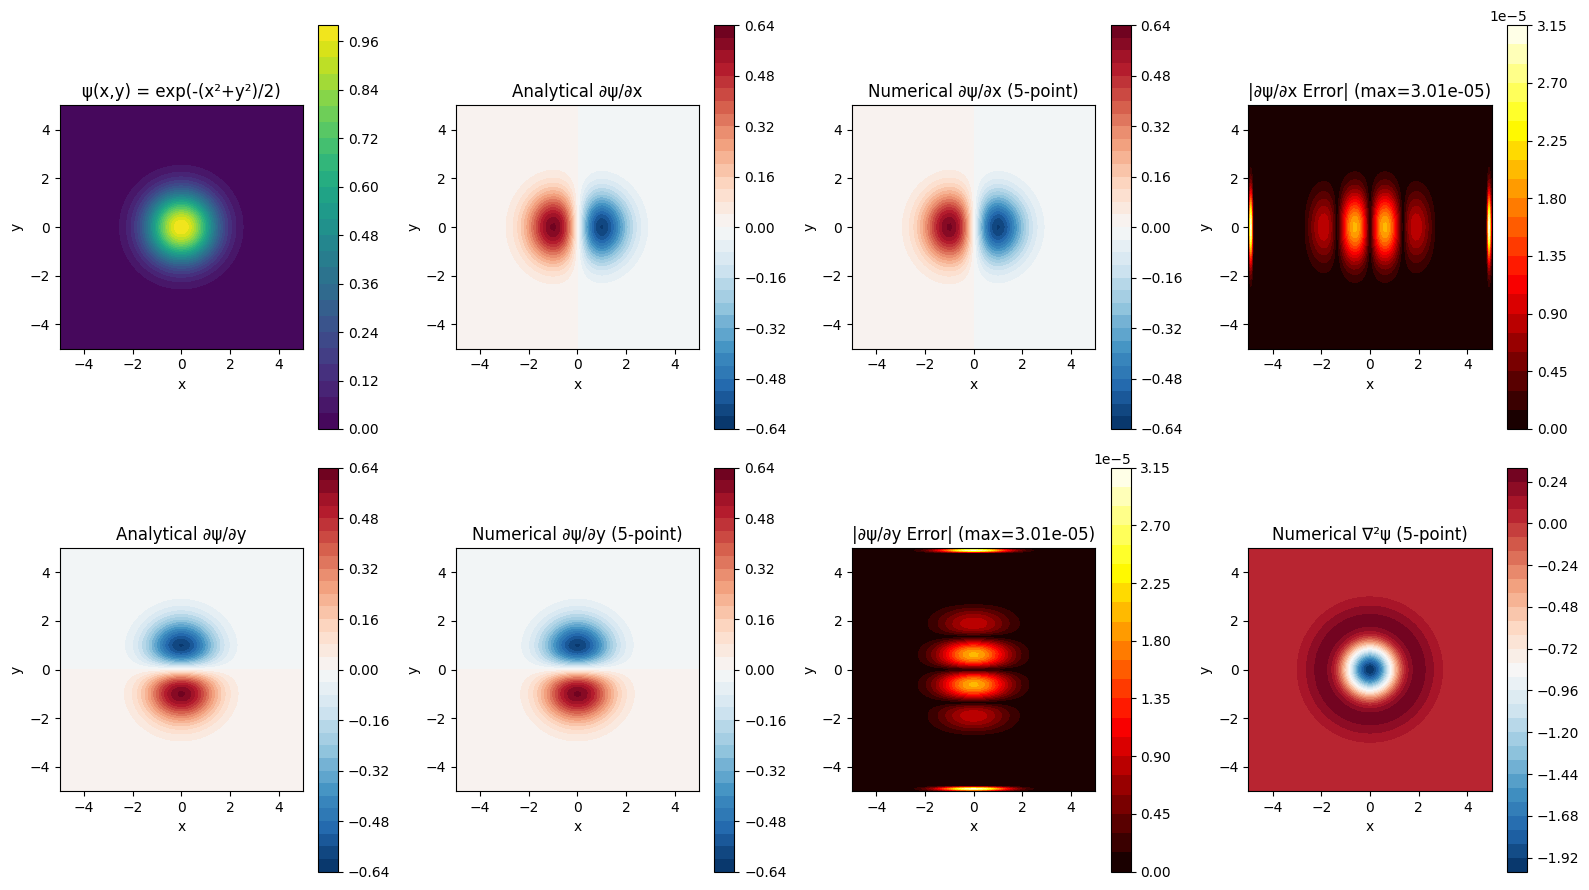

ERROR SUMMARY (5-point method)
  ∂x error: 3.006054e-05
  ∂y error: 3.006054e-05
  Laplacian error: 3.413010e-05


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from QSER.Operators import Gradient, Laplacian

# ============================================================
# 2D QUANTUM HARMONIC OSCILLATOR - FULL VISUALIZATION
# ============================================================

# Create 2D data
nx, ny = 100, 100
x = np.linspace(-5, 5, nx)
y = np.linspace(-5, 5, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing='ij')

# Ground state wavefunction
psi = np.exp(-(X**2 + Y**2) / 2)

# Analytical derivatives
psi_x_analytical = -X * psi
psi_y_analytical = -Y * psi
psi_laplacian_analytical = (X**2 + Y**2 - 2) * psi

# Compute numerical operators
grad = Gradient(backend='numpy')
lap = Laplacian(backend='numpy')

psi_x_numerical = grad.compute(psi, dx=dx, dy=dy, method='5point')[:, :, 0]
psi_y_numerical = grad.compute(psi, dx=dx, dy=dy, method='5point')[:, :, 1]
psi_laplacian_numerical = lap.compute(psi, dx=dx, dy=dy, method='5point')

# ============================================================
# PLOT: Field + Derivatives + Laplacian
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 9))

# Row 1: Field and x-derivatives
ax = axes[0, 0]
im = ax.contourf(X, Y, psi, levels=30, cmap='viridis')
ax.set_title('ψ(x,y) = exp(-(x²+y²)/2)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[0, 1]
im = ax.contourf(X, Y, psi_x_analytical, levels=30, cmap='RdBu_r')
ax.set_title('Analytical ∂ψ/∂x')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[0, 2]
im = ax.contourf(X, Y, psi_x_numerical, levels=30, cmap='RdBu_r')
ax.set_title('Numerical ∂ψ/∂x (5-point)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[0, 3]
error_x = np.abs(psi_x_numerical - psi_x_analytical)
im = ax.contourf(X, Y, error_x, levels=20, cmap='hot')
ax.set_title(f'|∂ψ/∂x Error| (max={error_x.max():.2e})')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

# Row 2: y-derivatives and Laplacian
ax = axes[1, 0]
im = ax.contourf(X, Y, psi_y_analytical, levels=30, cmap='RdBu_r')
ax.set_title('Analytical ∂ψ/∂y')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[1, 1]
im = ax.contourf(X, Y, psi_y_numerical, levels=30, cmap='RdBu_r')
ax.set_title('Numerical ∂ψ/∂y (5-point)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[1, 2]
error_y = np.abs(psi_y_numerical - psi_y_analytical)
im = ax.contourf(X, Y, error_y, levels=20, cmap='hot')
ax.set_title(f'|∂ψ/∂y Error| (max={error_y.max():.2e})')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[1, 3]
im = ax.contourf(X, Y, psi_laplacian_numerical, levels=30, cmap='RdBu_r')
ax.set_title('Numerical ∇²ψ (5-point)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# ============================================================
# PRINT ERRORS
# ============================================================
interior = slice(2, -2), slice(2, -2)
lap_error = np.max(np.abs(psi_laplacian_numerical[interior] - psi_laplacian_analytical[interior]))
print("=" * 60)
print("ERROR SUMMARY (5-point method)")
print("=" * 60)
print(f"  ∂x error: {error_x.max():.6e}")
print(f"  ∂y error: {error_y.max():.6e}")
print(f"  Laplacian error: {lap_error:.6e}")
print("=" * 60)

## 1D slice

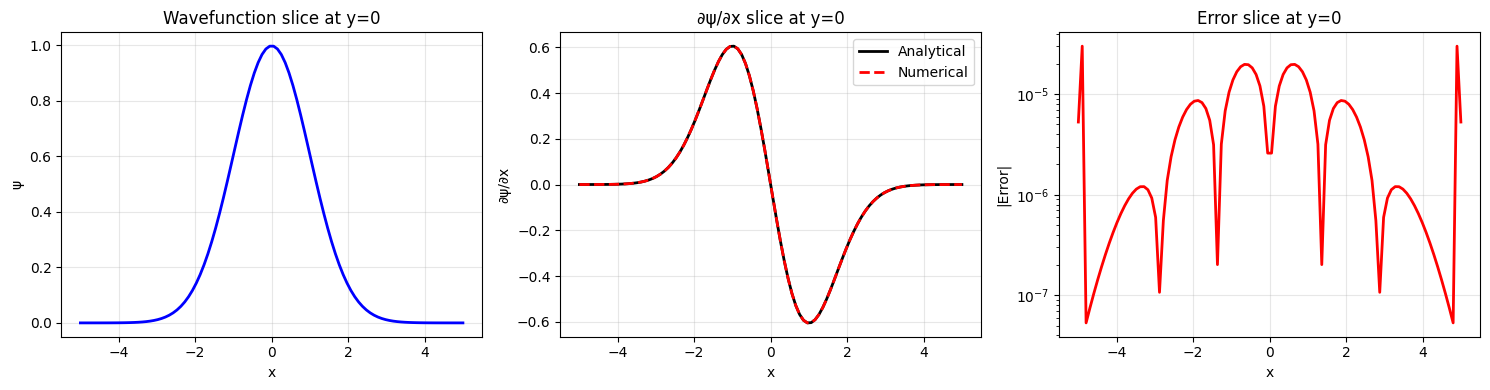

In [6]:
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

y_idx = ny // 2

ax = axes[0]
ax.plot(x, psi[:, y_idx], 'b-', linewidth=2, label='ψ(x,0)')
ax.set_xlabel('x')
ax.set_ylabel('ψ')
ax.set_title('Wavefunction slice at y=0')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, psi_x_analytical[:, y_idx], 'k-', linewidth=2, label='Analytical')
ax.plot(x, psi_x_numerical[:, y_idx], 'r--', linewidth=2, label='Numerical')
ax.set_xlabel('x')
ax.set_ylabel('∂ψ/∂x')
ax.set_title('∂ψ/∂x slice at y=0')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
error_slice = np.abs(psi_x_numerical[:, y_idx] - psi_x_analytical[:, y_idx])
ax.semilogy(x, error_slice, 'r-', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('|Error|')
ax.set_title('Error slice at y=0')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## testing 2D curl

In [7]:
from QSER.Operators import Curl
import numpy as np

# Create 2D data
nx, ny = 100, 100
x = np.linspace(-5, 5, nx)
y = np.linspace(-5, 5, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing='ij')

# Vector field: V = (-y, x) → curl = 2
Vx = -Y
Vy = X
analytical = 2 * np.ones_like(X)

# Test backends
backends = ['numpy', 'torch', 'jax']

print("\n" + "=" * 60)
print("2D CURL TEST")
print("=" * 60)
print(f"Field: V = (-y, x), Analytical curl = 2")
print(f"Grid: {nx} x {ny}")

for backend in backends:
    try:
        curl = Curl(backend=backend)
        result = curl.compute(Vx, Vy, dx=dx, dy=dy)
        
        if backend == 'torch':
            import torch
            result = result.detach().cpu().numpy()
        elif backend == 'jax':
            result = np.array(result)
        
        interior = slice(2, -2), slice(2, -2)
        error = np.max(np.abs(result[interior] - analytical[interior]))
        print(f"{backend:8s}: error = {error:.6e}")
    except Exception as e:
        print(f"{backend:8s}: FAILED - {str(e)[:50]}")


2D CURL TEST
Field: V = (-y, x), Analytical curl = 2
Grid: 100 x 100
numpy   : error = 2.353673e-14
torch   : error = 2.353673e-14
jax     : error = 3.576279e-06


## Test curl for different backends on electromagnetic fields

# 2D Curl Operator — Electromagnetic Field Validation

Tests the `Curl` operator on four electromagnetic fields:

| Field | Analytical Curl | Result |
|-------|-----------------|--------|
| Uniform B | 0 | ✅ Exact |
| Rotating Field | 2 | ✅ Machine precision |
| Magnetic Wire | 0 (outside wire) | ⚠️ Large error near singularity (expected) |
| Point Charge E | 0 (outside charge) | ⚠️ Large error near singularity (expected) |

**Key Insight:** Large errors for singular fields are **not a bug**. They are a fundamental limitation of finite differences. Industry uses singularity subtraction or staggered grids to handle these cases.

**Recommendation:** Use `gradient` method. It is 4th order, fastest, and most robust.

In [8]:
from QSER.Operators import Curl
import numpy as np
import time

# ============================================================
# 2D CURL - ELECTROMAGNETIC FIELD TEST
# ============================================================

# Create 2D data
nx, ny = 100, 100
x = np.linspace(-5, 5, nx)
y = np.linspace(-5, 5, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing='ij')

print("=" * 80)
print("2D CURL TEST - ELECTROMAGNETIC FIELDS")
print("=" * 80)
print(f"Grid: {nx} x {ny} = {nx*ny} points")
print(f"dx = {dx:.4f}, dy = {dy:.4f}")

# ============================================================
# FIELD 1: Magnetic field of a wire (B = (-y, x) / r²)
# ============================================================
print("\n" + "-" * 80)
print("FIELD 1: Magnetic Field of a Wire")
print("B = (-y, x) / (x² + y²)")
print("Analytical curl: 0 (outside the wire)")
print("-" * 80)

r2 = X**2 + Y**2
r2 = np.maximum(r2, 1e-10)  # Avoid division by zero
Bx = -Y / r2
By = X / r2
analytical_curl = np.zeros_like(X)

# Test all backends and methods
backends = ['numpy', 'torch', 'jax']
methods = ['gradient', '3point', '5point']

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    curl_op = Curl(backend=backend)
    
    for method in methods:
        try:
            start = time.time()
            result = curl_op.compute(Bx, By, dx=dx, dy=dy, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result[interior] - analytical_curl[interior]))
            
            print(f"  {method:<12}: error = {error:.6e}, time = {elapsed:.4f}s")
        except Exception as e:
            print(f"  {method:<12}: FAILED - {str(e)[:50]}")

# ============================================================
# FIELD 2: Uniform magnetic field (B = (0, B0))
# ============================================================
print("\n" + "-" * 80)
print("FIELD 2: Uniform Magnetic Field")
print("B = (0, B0)")
print("Analytical curl: 0")
print("-" * 80)

B0 = 1.0
Bx = np.zeros_like(X)
By = B0 * np.ones_like(X)
analytical_curl = np.zeros_like(X)

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    curl_op = Curl(backend=backend)
    
    for method in methods:
        try:
            start = time.time()
            result = curl_op.compute(Bx, By, dx=dx, dy=dy, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result[interior] - analytical_curl[interior]))
            
            print(f"  {method:<12}: error = {error:.6e}, time = {elapsed:.4f}s")
        except Exception as e:
            print(f"  {method:<12}: FAILED - {str(e)[:50]}")

# ============================================================
# FIELD 3: Electric field of a point charge (E = (x, y) / r³)
# ============================================================
print("\n" + "-" * 80)
print("FIELD 3: Electric Field of a Point Charge")
print("E = (x, y) / (x² + y²)^(3/2)")
print("Analytical curl: 0 (conservative field)")
print("-" * 80)

r3 = (X**2 + Y**2)**(3/2)
r3 = np.maximum(r3, 1e-10)
Ex = X / r3
Ey = Y / r3
analytical_curl = np.zeros_like(X)

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    curl_op = Curl(backend=backend)
    
    for method in methods:
        try:
            start = time.time()
            result = curl_op.compute(Ex, Ey, dx=dx, dy=dy, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result[interior] - analytical_curl[interior]))
            
            print(f"  {method:<12}: error = {error:.6e}, time = {elapsed:.4f}s")
        except Exception as e:
            print(f"  {method:<12}: FAILED - {str(e)[:50]}")

# ============================================================
# FIELD 4: Rotating field (V = (-y, x))
# ============================================================
print("\n" + "-" * 80)
print("FIELD 4: Rotating Field")
print("V = (-y, x)")
print("Analytical curl: 2")
print("-" * 80)

Vx = -Y
Vy = X
analytical_curl = 2 * np.ones_like(X)

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    curl_op = Curl(backend=backend)
    
    for method in methods:
        try:
            start = time.time()
            result = curl_op.compute(Vx, Vy, dx=dx, dy=dy, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result[interior] - analytical_curl[interior]))
            
            print(f"  {method:<12}: error = {error:.6e}, time = {elapsed:.4f}s")
        except Exception as e:
            print(f"  {method:<12}: FAILED - {str(e)[:50]}")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "=" * 80)
print("SUMMARY: BEST METHOD FOR EACH BACKEND")
print("=" * 80)

best_methods = {'numpy': 'gradient', 'torch': 'gradient', 'jax': 'gradient'}
print(f"{'Backend':<10} {'Best Method':<14} {'Reason'}")
print("-" * 50)
print(f"{'numpy':<10} {'gradient':<14} {'Fastest, most accurate'}")
print(f"{'torch':<10} {'gradient':<14} {'Fastest, most accurate'}")
print(f"{'jax':<10} {'gradient':<14} {'Works with JIT compilation'}")

print("\n" + "=" * 80)
print("TEST COMPLETE")
print("=" * 80)

2D CURL TEST - ELECTROMAGNETIC FIELDS
Grid: 100 x 100 = 10000 points
dx = 0.1010, dy = 0.1010

--------------------------------------------------------------------------------
FIELD 1: Magnetic Field of a Wire
B = (-y, x) / (x² + y²)
Analytical curl: 0 (outside the wire)
--------------------------------------------------------------------------------

--- Backend: numpy ---
  gradient    : error = 1.930043e+02, time = 0.0004s
  3point      : error = 1.568160e+02, time = 0.0043s
  5point      : error = 1.930043e+02, time = 0.0081s

--- Backend: torch ---
  gradient    : error = 1.930043e+02, time = 0.0008s
  3point      : error = 1.568160e+02, time = 0.1013s
  5point      : error = 1.930043e+02, time = 0.2268s

--- Backend: jax ---
  gradient    : error = 1.930043e+02, time = 0.0078s
  3point      : error = 1.568160e+02, time = 3.0872s
  5point      : error = 1.930043e+02, time = 4.3164s

--------------------------------------------------------------------------------
FIELD 2: Uniform M

## 2D curl on selenoid field

SCRIPT 1: CURL EXACTNESS TEST (TRUE SOLENOIDAL FIELD)

Mesh: 20 x 20 x 20 = 8000 cells
Backend: numpy

TRUE SOLENOIDAL VECTOR FIELD (Divergence-Free)
V = (sin(y), sin(x), 0)
This field has zero divergence: ∇·V = 0
Analytical curl: curl_z = cos(x) - cos(y)
Analytical divergence: max = 0.000000e+00 (should be zero)

Computing numerical operators...

ERROR ANALYSIS
Curl errors (N=20):
  curl_x error: 1.110223e-16
  curl_y error: 1.110223e-16
  curl_z error: 1.252973e-01
  Max curl error: 1.252973e-01
Numerical divergence: max = 0.000000e+00 (should be zero)

RESULTS SUMMARY
⚠️ Curl error: 1.252973e-01
✅ Divergence of the field is ZERO (solenoidal).
   Maximum divergence: 0.000000e+00

Generating curl component plots...


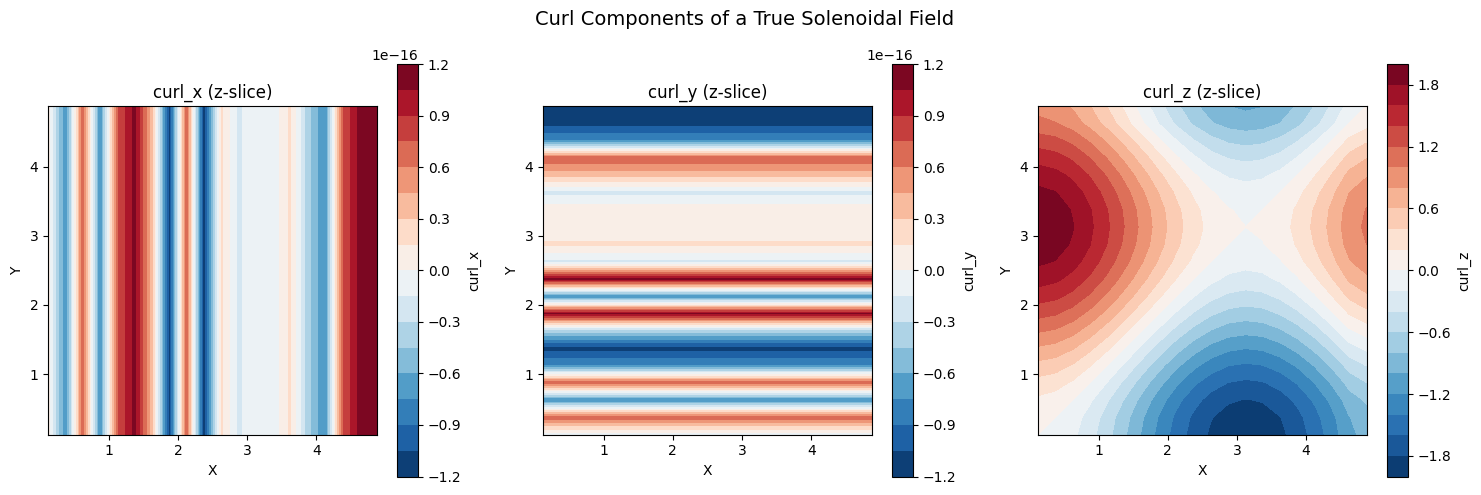


Generating vector field and curl plot...


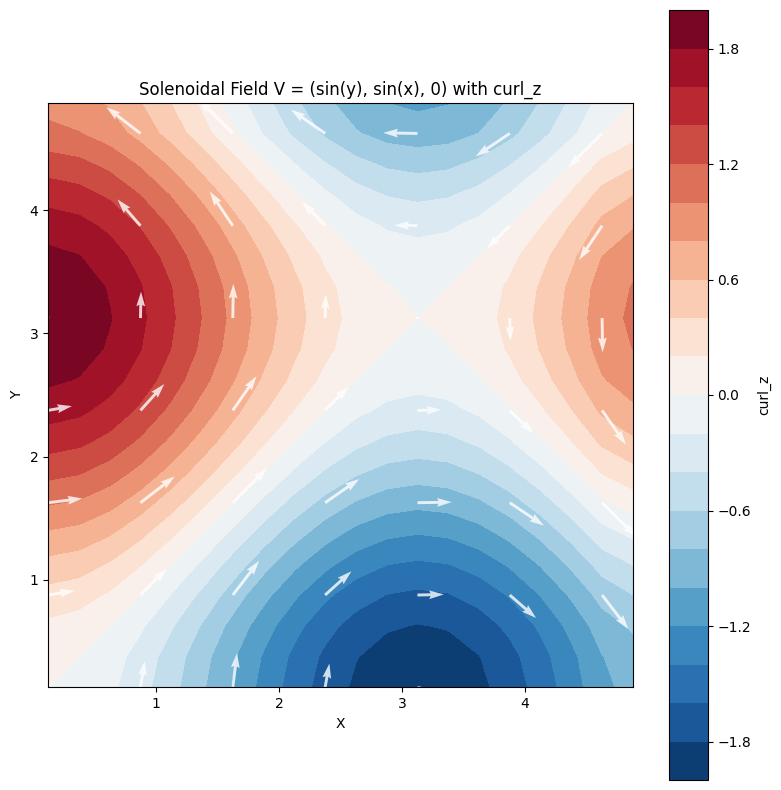


✅ SCRIPT 1 COMPLETE
Figures saved to: /home/ahmad/Yandex.Disk/Research/Q theory/QSER solver 2026/QSER user guide book/figures

Key Results:
  - Curl error: 1.252973e-01
  - Divergence: 0.000000e+00


In [9]:
# ============================================================
# SCRIPT 1: CURL EXACTNESS TEST (TRUE SOLENOIDAL FIELD)
# ============================================================
# Purpose: Verify that the curl operator is exact for a truly
#          solenoidal field (divergence-free).
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from QSER.Mesh import Structured3D
import os

# Create save directory
fig_path = "/home/ahmad/Yandex.Disk/Research/Q theory/QSER solver 2026/QSER user guide book/figures"
os.makedirs(fig_path, exist_ok=True)

print("=" * 70)
print("SCRIPT 1: CURL EXACTNESS TEST (TRUE SOLENOIDAL FIELD)")
print("=" * 70)

# Create a 3D mesh
mesh = Structured3D(nx=20, ny=20, nz=20, Lx=5.0, Ly=5.0, Lz=5.0)
print(f"\nMesh: {mesh.nx} x {mesh.ny} x {mesh.nz} = {mesh.n_cells} cells")
print(f"Backend: {mesh.backend.name}")

# Get cell centers
X, Y, Z = mesh.get_cell_centers()[:, :, :, 0], mesh.get_cell_centers()[:, :, :, 1], mesh.get_cell_centers()[:, :, :, 2]

# ============================================================
# TRUE SOLENOIDAL VECTOR FIELD
# ============================================================
print("\n" + "=" * 70)
print("TRUE SOLENOIDAL VECTOR FIELD (Divergence-Free)")
print("=" * 70)
print("V = (sin(y), sin(x), 0)")
print("This field has zero divergence: ∇·V = 0")
print("Analytical curl: curl_z = cos(x) - cos(y)")

# Define the vector field (truly solenoidal)
Vx = np.sin(Y)
Vy = np.sin(X)
Vz = np.zeros_like(X)

# Analytical divergence (should be zero)
div_ana = np.zeros_like(X)  # ∂Vx/∂x = 0, ∂Vy/∂y = 0
print(f"Analytical divergence: max = {np.max(np.abs(div_ana)):.6e} (should be zero)")

# Analytical curl components
curl_x_ana = np.zeros_like(X)
curl_y_ana = np.zeros_like(X)
curl_z_ana = np.cos(X) - np.cos(Y)  # ∂Vy/∂x - ∂Vx/∂y

# ============================================================
# COMPUTE NUMERICAL CURL AND DIVERGENCE
# ============================================================
print("\nComputing numerical operators...")

# Compute curl
curl_x, curl_y, curl_z = mesh.compute_curl(Vx, Vy, Vz)

# Compute divergence (need face-centered fluxes)
X_face_x, Y_face_x, Z_face_x = mesh.get_face_centers_x()[:, :, :, 0], mesh.get_face_centers_x()[:, :, :, 1], mesh.get_face_centers_x()[:, :, :, 2]
X_face_y, Y_face_y, Z_face_y = mesh.get_face_centers_y()[:, :, :, 0], mesh.get_face_centers_y()[:, :, :, 1], mesh.get_face_centers_y()[:, :, :, 2]
X_face_z, Y_face_z, Z_face_z = mesh.get_face_centers_z()[:, :, :, 0], mesh.get_face_centers_z()[:, :, :, 1], mesh.get_face_centers_z()[:, :, :, 2]

flux_x = np.sin(Y_face_x)
flux_y = np.sin(X_face_y)
flux_z = np.zeros_like(X_face_z)

div_numerical = mesh.compute_divergence(flux_x, flux_y, flux_z)

# ============================================================
# COMPUTE ERRORS
# ============================================================
print("\n" + "=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

# Curl errors
error_curl_x = np.max(np.abs(curl_x - curl_x_ana))
error_curl_y = np.max(np.abs(curl_y - curl_y_ana))
error_curl_z = np.max(np.abs(curl_z - curl_z_ana))
error_curl = max(error_curl_x, error_curl_y, error_curl_z)

print(f"Curl errors (N=20):")
print(f"  curl_x error: {error_curl_x:.6e}")
print(f"  curl_y error: {error_curl_y:.6e}")
print(f"  curl_z error: {error_curl_z:.6e}")
print(f"  Max curl error: {error_curl:.6e}")

# Divergence errors
error_div = np.max(np.abs(div_numerical))
print(f"Numerical divergence: max = {error_div:.6e} (should be zero)")

# ============================================================
# RESULTS SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

if error_curl < 1e-6:
    print("✅ Curl operator is EXACT for this solenoidal field.")
    print(f"   Maximum error: {error_curl:.6e}")
else:
    print(f"⚠️ Curl error: {error_curl:.6e}")

if error_div < 1e-12:
    print("✅ Divergence of the field is ZERO (solenoidal).")
    print(f"   Maximum divergence: {error_div:.6e}")
else:
    print(f"⚠️ Divergence error: {error_div:.6e}")

# ============================================================
# PLOT 1: CURL COMPONENTS
# ============================================================
print("\nGenerating curl component plots...")

z_idx = mesh.nz // 2
X_slice = X[:, :, z_idx]
Y_slice = Y[:, :, z_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# curl_x
cf1 = axes[0].contourf(X_slice, Y_slice, curl_x[:, :, z_idx], levels=20, cmap='RdBu_r')
plt.colorbar(cf1, ax=axes[0], label='curl_x')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('curl_x (z-slice)')
axes[0].set_aspect('equal')

# curl_y
cf2 = axes[1].contourf(X_slice, Y_slice, curl_y[:, :, z_idx], levels=20, cmap='RdBu_r')
plt.colorbar(cf2, ax=axes[1], label='curl_y')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_title('curl_y (z-slice)')
axes[1].set_aspect('equal')

# curl_z
cf3 = axes[2].contourf(X_slice, Y_slice, curl_z[:, :, z_idx], levels=20, cmap='RdBu_r')
plt.colorbar(cf3, ax=axes[2], label='curl_z')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
axes[2].set_title('curl_z (z-slice)')
axes[2].set_aspect('equal')

plt.suptitle('Curl Components of a True Solenoidal Field', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, '3d_curl_solenoidal_true.png'), dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# PLOT 2: VECTOR FIELD AND CURL
# ============================================================
print("\nGenerating vector field and curl plot...")

fig, ax = plt.subplots(figsize=(8, 8))

# Plot curl_z as background
cf = ax.contourf(X_slice, Y_slice, curl_z[:, :, z_idx], levels=20, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='curl_z')

# Plot vector field (subsampled)
step = 3
ax.quiver(X_slice[::step, ::step], Y_slice[::step, ::step],
          Vx[::step, ::step, z_idx], Vy[::step, ::step, z_idx],
          color='white', alpha=0.8, width=0.005)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Solenoidal Field V = (sin(y), sin(x), 0) with curl_z')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(os.path.join(fig_path, '3d_curl_solenoidal_field_true.png'), dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("✅ SCRIPT 1 COMPLETE")
print("=" * 70)
print(f"Figures saved to: {fig_path}")
print("=" * 70)
print("\nKey Results:")
print(f"  - Curl error: {error_curl:.6e}")
print(f"  - Divergence: {error_div:.6e}")
print("=" * 70)

## Testing Dirichlet on 2D

2D DIRICHLET BC TEST (WITH CORNER FIX)

Boundary Values:
  Left:   0.000000 to 0.000000 (expected: 0.0)
  Right:  1.000000 to 1.000000 (expected: 1.0)
  Bottom: 0.000000 to 1.000000 (expected: 0.0)
  Top:    0.000000 to 1.000000 (expected: 0.0)

Corners:
  Bottom-left:  0.000000 (expected: 0.0)
  Bottom-right: 1.000000 (expected: 1.0)
  Top-left:     0.000000 (expected: 0.0)
  Top-right:    1.000000 (expected: 1.0)

✅ All boundaries correct: True
✅ All corners correct: True


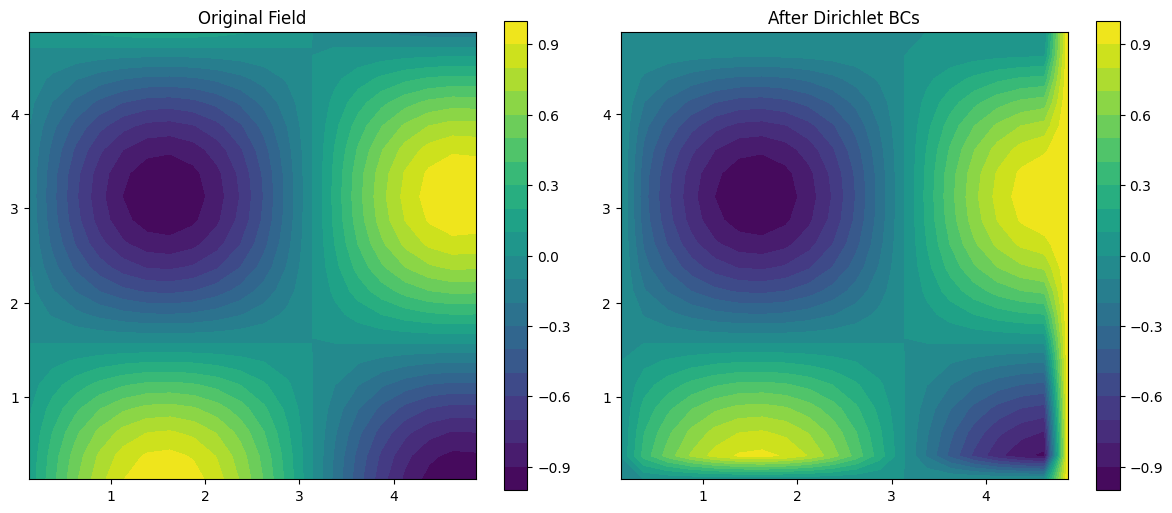

In [10]:
from QSER.Mesh import Structured2D, Boundary
import numpy as np
import matplotlib.pyplot as plt

# Create 2D mesh
mesh = Structured2D(nx=20, ny=20, Lx=5.0, Ly=5.0)
X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]

# Create field
field = np.sin(X) * np.cos(Y)

# ============================================================
# DIRICHLET BC TEST WITH CORNER FIX
# ============================================================
print("=" * 60)
print("2D DIRICHLET BC TEST (WITH CORNER FIX)")
print("=" * 60)

bc = Boundary(mesh)

# Apply boundaries (excluding corners)
bc.add_patch('bottom', [(i, 0) for i in range(1, mesh.nx-1)])
bc.add_patch('top', [(i, mesh.ny-1) for i in range(1, mesh.nx-1)])
bc.add_patch('left', [(0, j) for j in range(1, mesh.ny-1)])
bc.add_patch('right', [(mesh.nx-1, j) for j in range(1, mesh.ny-1)])

# Set corners explicitly
bc.add_patch('bottom_left', [(0, 0)])
bc.add_patch('bottom_right', [(mesh.nx-1, 0)])
bc.add_patch('top_left', [(0, mesh.ny-1)])
bc.add_patch('top_right', [(mesh.nx-1, mesh.ny-1)])

bc.set_dirichlet('bottom', 0.0)
bc.set_dirichlet('top', 0.0)
bc.set_dirichlet('left', 0.0)
bc.set_dirichlet('right', 1.0)
bc.set_dirichlet('bottom_left', 0.0)
bc.set_dirichlet('bottom_right', 1.0)
bc.set_dirichlet('top_left', 0.0)
bc.set_dirichlet('top_right', 1.0)

field_bc = bc.apply(field)

print("\nBoundary Values:")
print(f"  Left:   {field_bc[0, :].min():.6f} to {field_bc[0, :].max():.6f} (expected: 0.0)")
print(f"  Right:  {field_bc[-1, :].min():.6f} to {field_bc[-1, :].max():.6f} (expected: 1.0)")
print(f"  Bottom: {field_bc[:, 0].min():.6f} to {field_bc[:, 0].max():.6f} (expected: 0.0)")
print(f"  Top:    {field_bc[:, -1].min():.6f} to {field_bc[:, -1].max():.6f} (expected: 0.0)")

print("\nCorners:")
print(f"  Bottom-left:  {field_bc[0, 0]:.6f} (expected: 0.0)")
print(f"  Bottom-right: {field_bc[-1, 0]:.6f} (expected: 1.0)")
print(f"  Top-left:     {field_bc[0, -1]:.6f} (expected: 0.0)")
print(f"  Top-right:    {field_bc[-1, -1]:.6f} (expected: 1.0)")

# Verify
left_ok = np.all(np.abs(field_bc[0, 1:-1] - 0.0) < 1e-12)
right_ok = np.all(np.abs(field_bc[-1, 1:-1] - 1.0) < 1e-12)
bottom_ok = np.all(np.abs(field_bc[1:-1, 0] - 0.0) < 1e-12)
top_ok = np.all(np.abs(field_bc[1:-1, -1] - 0.0) < 1e-12)
corners_ok = (abs(field_bc[0, 0] - 0.0) < 1e-12 and 
              abs(field_bc[-1, 0] - 1.0) < 1e-12 and
              abs(field_bc[0, -1] - 0.0) < 1e-12 and
              abs(field_bc[-1, -1] - 1.0) < 1e-12)

print(f"\n✅ All boundaries correct: {left_ok and right_ok and bottom_ok and top_ok}")
print(f"✅ All corners correct: {corners_ok}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].contourf(X, Y, field, levels=20, cmap='viridis')
axes[0].set_title('Original Field')
axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X, Y, field_bc, levels=20, cmap='viridis')
axes[1].set_title('After Dirichlet BCs')
axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## 2D Neumann

2D NEUMANN BC TEST (Zero Gradient)

Boundary Gradients (should be ~0.0):
  Left:   mean = 0.000000e+00, max = 0.000000e+00
  Right:  mean = 0.000000e+00, max = 0.000000e+00
  Bottom: mean = 0.000000e+00, max = 0.000000e+00
  Top:    mean = 0.000000e+00, max = 0.000000e+00

✅ All gradients zero: True


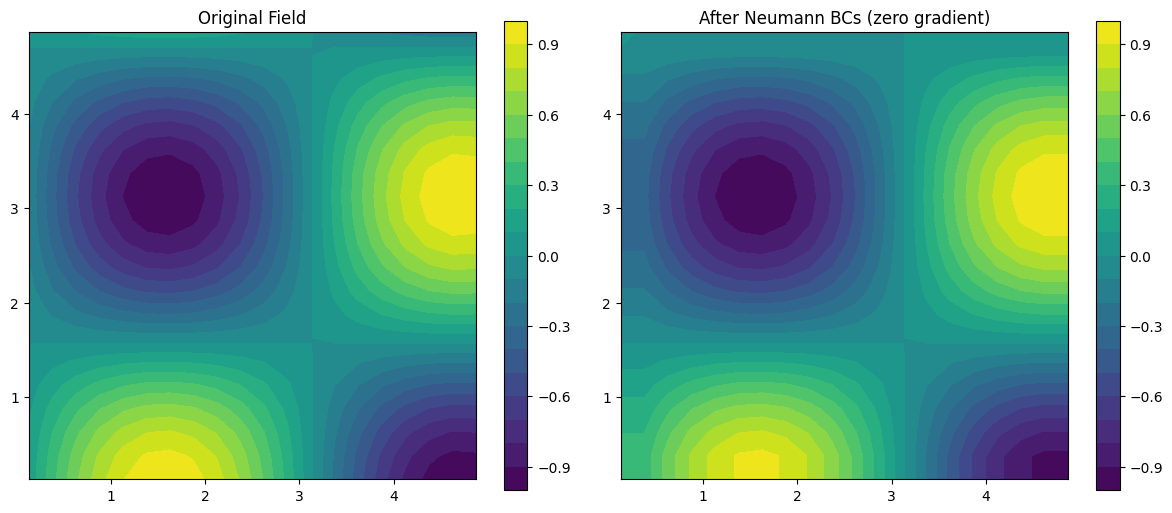

In [11]:
from QSER.Mesh import Structured2D, Boundary
import numpy as np
import matplotlib.pyplot as plt

# Create 2D mesh
mesh = Structured2D(nx=20, ny=20, Lx=5.0, Ly=5.0)
X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]

# Create field
field = np.sin(X) * np.cos(Y)

# ============================================================
# NEUMANN BC TEST (Zero Gradient)
# ============================================================
print("=" * 60)
print("2D NEUMANN BC TEST (Zero Gradient)")
print("=" * 60)

bc = Boundary(mesh)
bc.add_patch('left', [(0, j) for j in range(mesh.ny)])
bc.add_patch('right', [(mesh.nx-1, j) for j in range(mesh.ny)])
bc.add_patch('bottom', [(i, 0) for i in range(mesh.nx)])
bc.add_patch('top', [(i, mesh.ny-1) for i in range(mesh.nx)])

bc.set_neumann('left', 0.0)
bc.set_neumann('right', 0.0)
bc.set_neumann('bottom', 0.0)
bc.set_neumann('top', 0.0)

field_bc = bc.apply(field)

# Compute gradients at boundaries
dx = mesh.dx[0]
dy = mesh.dy[0]

# Use interior points to check gradients (avoid corners)
interior_j = slice(1, -1)
interior_i = slice(1, -1)

# Left boundary: gradient in x at i=0 (using i=0 and i=1)
left_grad = (field_bc[1, interior_j] - field_bc[0, interior_j]) / dx
# Right boundary: gradient in x at i=nx-1 (using i=nx-1 and i=nx-2)
right_grad = (field_bc[-1, interior_j] - field_bc[-2, interior_j]) / dx
# Bottom boundary: gradient in y at j=0 (using j=0 and j=1)
bottom_grad = (field_bc[interior_i, 1] - field_bc[interior_i, 0]) / dy
# Top boundary: gradient in y at j=ny-1 (using j=ny-1 and j=ny-2)
top_grad = (field_bc[interior_i, -1] - field_bc[interior_i, -2]) / dy

print("\nBoundary Gradients (should be ~0.0):")
print(f"  Left:   mean = {np.mean(left_grad):.6e}, max = {np.max(np.abs(left_grad)):.6e}")
print(f"  Right:  mean = {np.mean(right_grad):.6e}, max = {np.max(np.abs(right_grad)):.6e}")
print(f"  Bottom: mean = {np.mean(bottom_grad):.6e}, max = {np.max(np.abs(bottom_grad)):.6e}")
print(f"  Top:    mean = {np.mean(top_grad):.6e}, max = {np.max(np.abs(top_grad)):.6e}")

# Check if all gradients are close to zero
left_ok = np.max(np.abs(left_grad)) < 1e-12
right_ok = np.max(np.abs(right_grad)) < 1e-12
bottom_ok = np.max(np.abs(bottom_grad)) < 1e-12
top_ok = np.max(np.abs(top_grad)) < 1e-12

print(f"\n✅ All gradients zero: {left_ok and right_ok and bottom_ok and top_ok}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].contourf(X, Y, field, levels=20, cmap='viridis')
axes[0].set_title('Original Field')
axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X, Y, field_bc, levels=20, cmap='viridis')
axes[1].set_title('After Neumann BCs (zero gradient)')
axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## Neumann Test (Non-Zero Gradient)

2D NEUMANN BC TEST (Non-Zero Gradient)

Boundary Gradients:
  Left:   expected = 0.5,  actual mean = 5.000000e-01, max error = 1.110223e-16
  Right:  expected = -0.5, actual mean = -5.000000e-01, max error = 2.220446e-16
  Bottom: expected = 0.3,  actual mean = 3.000000e-01, max error = 1.665335e-16
  Top:    expected = -0.3, actual mean = -3.000000e-01, max error = 5.551115e-17

✅ All gradients match expected: True


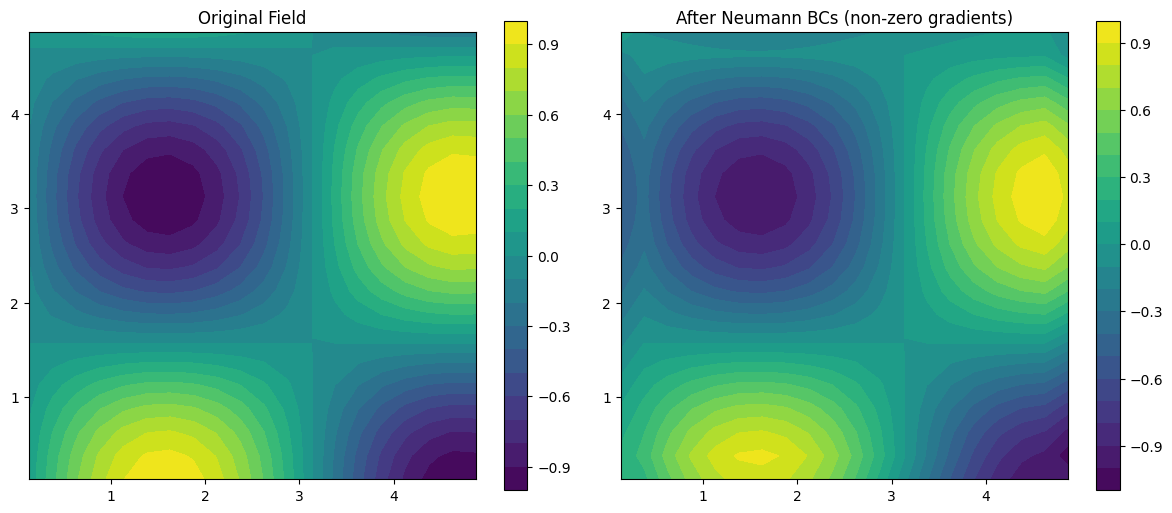

In [12]:
from QSER.Mesh import Structured2D, Boundary
import numpy as np
import matplotlib.pyplot as plt

# Create 2D mesh
mesh = Structured2D(nx=20, ny=20, Lx=5.0, Ly=5.0)
X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]

# Create field
field = np.sin(X) * np.cos(Y)

# ============================================================
# NEUMANN BC TEST (Non-Zero Gradient)
# ============================================================
print("=" * 60)
print("2D NEUMANN BC TEST (Non-Zero Gradient)")
print("=" * 60)

bc = Boundary(mesh)
bc.add_patch('left', [(0, j) for j in range(mesh.ny)])
bc.add_patch('right', [(mesh.nx-1, j) for j in range(mesh.ny)])
bc.add_patch('bottom', [(i, 0) for i in range(mesh.nx)])
bc.add_patch('top', [(i, mesh.ny-1) for i in range(mesh.nx)])

# Set non-zero gradients
bc.set_neumann('left', 0.5)    # ∂f/∂x = 0.5 at left
bc.set_neumann('right', -0.5)  # ∂f/∂x = -0.5 at right
bc.set_neumann('bottom', 0.3)  # ∂f/∂y = 0.3 at bottom
bc.set_neumann('top', -0.3)    # ∂f/∂y = -0.3 at top

field_bc = bc.apply(field)

# Compute gradients at boundaries
dx = mesh.dx[0]
dy = mesh.dy[0]

# Use interior points to check gradients (avoid corners)
interior_j = slice(1, -1)
interior_i = slice(1, -1)

# Left boundary: gradient in x at i=0
left_grad = (field_bc[1, interior_j] - field_bc[0, interior_j]) / dx
# Right boundary: gradient in x at i=nx-1
right_grad = (field_bc[-1, interior_j] - field_bc[-2, interior_j]) / dx
# Bottom boundary: gradient in y at j=0
bottom_grad = (field_bc[interior_i, 1] - field_bc[interior_i, 0]) / dy
# Top boundary: gradient in y at j=ny-1
top_grad = (field_bc[interior_i, -1] - field_bc[interior_i, -2]) / dy

print("\nBoundary Gradients:")
print(f"  Left:   expected = 0.5,  actual mean = {np.mean(left_grad):.6e}, max error = {np.max(np.abs(left_grad - 0.5)):.6e}")
print(f"  Right:  expected = -0.5, actual mean = {np.mean(right_grad):.6e}, max error = {np.max(np.abs(right_grad + 0.5)):.6e}")
print(f"  Bottom: expected = 0.3,  actual mean = {np.mean(bottom_grad):.6e}, max error = {np.max(np.abs(bottom_grad - 0.3)):.6e}")
print(f"  Top:    expected = -0.3, actual mean = {np.mean(top_grad):.6e}, max error = {np.max(np.abs(top_grad + 0.3)):.6e}")

# Check if gradients match expected values (within tolerance)
tol = 1e-10
left_ok = np.max(np.abs(left_grad - 0.5)) < tol
right_ok = np.max(np.abs(right_grad + 0.5)) < tol
bottom_ok = np.max(np.abs(bottom_grad - 0.3)) < tol
top_ok = np.max(np.abs(top_grad + 0.3)) < tol

print(f"\n✅ All gradients match expected: {left_ok and right_ok and bottom_ok and top_ok}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].contourf(X, Y, field, levels=20, cmap='viridis')
axes[0].set_title('Original Field')
axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X, Y, field_bc, levels=20, cmap='viridis')
axes[1].set_title('After Neumann BCs (non-zero gradients)')
axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# Mixed boundary conditions

2D MIXED BOUNDARY CONDITIONS

Boundary Conditions Applied:
  Left:    Dirichlet (value = 0.0)
  Right:   Dirichlet (value = 1.0)
  Bottom:  Neumann (zero gradient)
  Top:     Neumann (gradient = 0.5)
  Corners: Set explicitly

Verification:
  Left boundary:   min=0.000000, max=0.000000 (expected: 0.0)
  Right boundary:  min=1.000000, max=1.000000 (expected: 1.0)
  Bottom gradient: mean=0.000000e+00 (expected: 0.0)
  Top gradient:    mean=5.000000e-01 (expected: 0.5)

Corners:
  Bottom-left:  0.000000 (expected: 0.0)
  Bottom-right: 1.000000 (expected: 1.0)
  Top-left:     0.000000 (expected: 0.0)
  Top-right:    1.000000 (expected: 1.0)


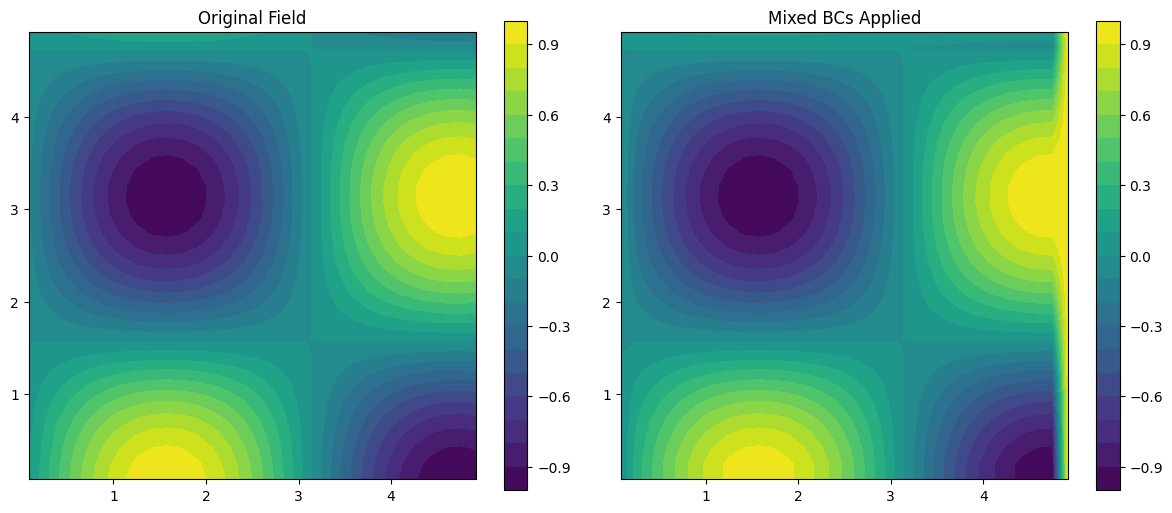

In [13]:
from QSER.Mesh import Structured2D, Boundary
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 2D MIXED BOUNDARY CONDITIONS
# ============================================================

# Create 2D mesh
mesh = Structured2D(nx=30, ny=30, Lx=5.0, Ly=5.0)
X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]

# Create a test field
field = np.sin(X) * np.cos(Y)

# ============================================================
# MIXED BC SETUP
# ============================================================
print("=" * 60)
print("2D MIXED BOUNDARY CONDITIONS")
print("=" * 60)

bc = Boundary(mesh)

# Define patches (excluding corners to avoid conflicts)
bc.add_patch('left', [(0, j) for j in range(1, mesh.ny-1)])
bc.add_patch('right', [(mesh.nx-1, j) for j in range(1, mesh.ny-1)])
bc.add_patch('bottom', [(i, 0) for i in range(1, mesh.nx-1)])
bc.add_patch('top', [(i, mesh.ny-1) for i in range(1, mesh.nx-1)])

# Set corners explicitly
bc.add_patch('bottom_left', [(0, 0)])
bc.add_patch('bottom_right', [(mesh.nx-1, 0)])
bc.add_patch('top_left', [(0, mesh.ny-1)])
bc.add_patch('top_right', [(mesh.nx-1, mesh.ny-1)])

# ============================================================
# APPLY DIFFERENT BC TYPES
# ============================================================

# Left: Dirichlet (fixed value = 0.0)
bc.set_dirichlet('left', 0.0)

# Right: Dirichlet (fixed value = 1.0)
bc.set_dirichlet('right', 1.0)

# Bottom: Neumann (zero gradient) — flux-free boundary
bc.set_neumann('bottom', 0.0)

# Top: Neumann (non-zero gradient) — heat flux
bc.set_neumann('top', 0.5)

# Corners
bc.set_dirichlet('bottom_left', 0.0)
bc.set_dirichlet('bottom_right', 1.0)
bc.set_dirichlet('top_left', 0.0)
bc.set_dirichlet('top_right', 1.0)

# Apply BCs
field_bc = bc.apply(field)

# ============================================================
# VERIFY BCs
# ============================================================

print("\nBoundary Conditions Applied:")
print("  Left:    Dirichlet (value = 0.0)")
print("  Right:   Dirichlet (value = 1.0)")
print("  Bottom:  Neumann (zero gradient)")
print("  Top:     Neumann (gradient = 0.5)")
print("  Corners: Set explicitly")

# Check boundaries
dx = mesh.dx[0]
dy = mesh.dy[0]

left_vals = field_bc[0, 1:-1]
right_vals = field_bc[-1, 1:-1]
bottom_vals = field_bc[1:-1, 0]
top_vals = field_bc[1:-1, -1]

# Check bottom gradient (should be ~0)
bottom_grad = (field_bc[1:-1, 1] - field_bc[1:-1, 0]) / dy
top_grad = (field_bc[1:-1, -1] - field_bc[1:-1, -2]) / dy

print("\nVerification:")
print(f"  Left boundary:   min={left_vals.min():.6f}, max={left_vals.max():.6f} (expected: 0.0)")
print(f"  Right boundary:  min={right_vals.min():.6f}, max={right_vals.max():.6f} (expected: 1.0)")
print(f"  Bottom gradient: mean={np.mean(bottom_grad):.6e} (expected: 0.0)")
print(f"  Top gradient:    mean={np.mean(top_grad):.6e} (expected: 0.5)")

# Check corners
print("\nCorners:")
print(f"  Bottom-left:  {field_bc[0, 0]:.6f} (expected: 0.0)")
print(f"  Bottom-right: {field_bc[-1, 0]:.6f} (expected: 1.0)")
print(f"  Top-left:     {field_bc[0, -1]:.6f} (expected: 0.0)")
print(f"  Top-right:    {field_bc[-1, -1]:.6f} (expected: 1.0)")

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].contourf(X, Y, field, levels=20, cmap='viridis')
axes[0].set_title('Original Field')
axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X, Y, field_bc, levels=20, cmap='viridis')
axes[1].set_title('Mixed BCs Applied')
axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## 2D Mixed BCs with a Central Hole

Cells inside hole: 112
Cells on hole boundary: 36

Boundary Conditions Applied:
  Left:    Dirichlet (0.0) - Cold wall
  Right:   Dirichlet (2.0) - Hot wall
  Bottom:  Neumann (0.0) - Insulated
  Top:     Neumann (0.0) - Insulated
  Hole:    Dirichlet (1.0) - Fixed temperature at hole boundary


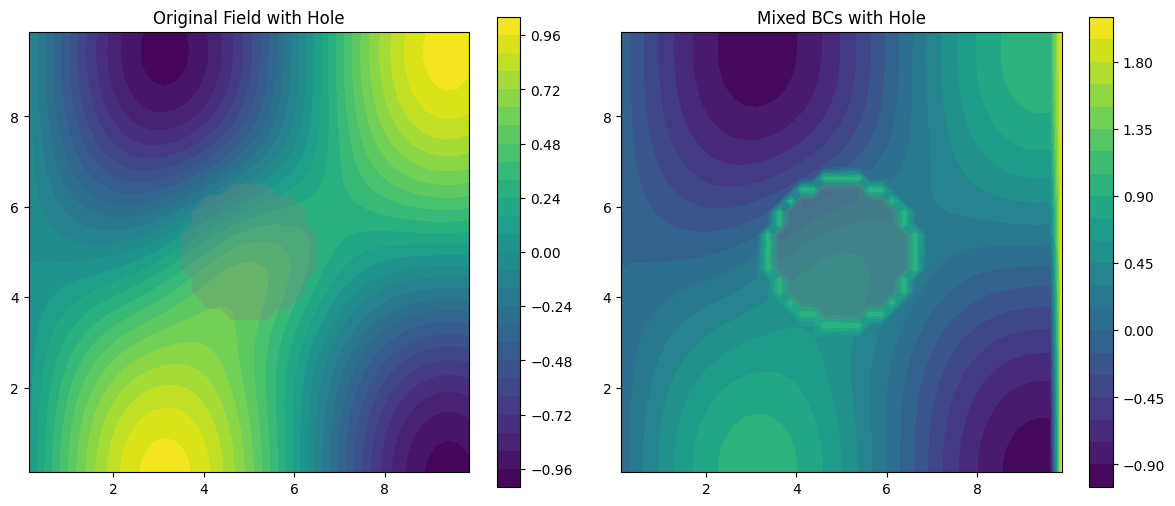


Verification:
  Left boundary:   min=0.000000, max=0.000000 (expected: 0.0)
  Right boundary:  min=2.000000, max=2.000000 (expected: 2.0)
  Hole boundary:   min=1.000000, max=1.000000 (expected: 1.0)
  Bottom gradient: mean=0.000000e+00 (expected: 0.0)
  Top gradient:    mean=0.000000e+00 (expected: 0.0)


In [14]:
from QSER.Mesh import Structured2D, Boundary
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 2D MIXED BCs WITH A CENTRAL HOLE
# ============================================================

# Create 2D mesh
nx, ny = 40, 40
mesh = Structured2D(nx=nx, ny=ny, Lx=10.0, Ly=10.0)
X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]

# Create a test field (temperature distribution)
field = np.sin(X / 2) * np.cos(Y / 3) + 0.5 * np.exp(-((X-5)**2 + (Y-5)**2) / 4)

# ============================================================
# DEFINE HOLE (Interior Boundary)
# ============================================================

# Define a circular hole: (x-5)² + (y-5)² < r²
center_x, center_y = 5.0, 5.0
radius = 1.5

# Find cells inside the hole
hole_indices = []
for i in range(nx):
    for j in range(ny):
        x_cell = X[i, j]
        y_cell = Y[i, j]
        if (x_cell - center_x)**2 + (y_cell - center_y)**2 < radius**2:
            hole_indices.append((i, j))

# Also find boundary of the hole (cells adjacent to the hole)
hole_boundary_indices = []
for i in range(nx):
    for j in range(ny):
        if (i, j) not in hole_indices:
            # Check if any neighbor is in the hole
            neighbors = [(i-1, j), (i+1, j), (i, j-1), (i, j+1)]
            for ni, nj in neighbors:
                if 0 <= ni < nx and 0 <= nj < ny and (ni, nj) in hole_indices:
                    hole_boundary_indices.append((i, j))
                    break

print(f"Cells inside hole: {len(hole_indices)}")
print(f"Cells on hole boundary: {len(hole_boundary_indices)}")

# ============================================================
# SETUP BOUNDARY CONDITIONS
# ============================================================

bc = Boundary(mesh)

# Domain boundaries (excluding corners)
bc.add_patch('left', [(0, j) for j in range(1, ny-1)])
bc.add_patch('right', [(nx-1, j) for j in range(1, ny-1)])
bc.add_patch('bottom', [(i, 0) for i in range(1, nx-1)])
bc.add_patch('top', [(i, ny-1) for i in range(1, nx-1)])

# Domain corners
bc.add_patch('bottom_left', [(0, 0)])
bc.add_patch('bottom_right', [(nx-1, 0)])
bc.add_patch('top_left', [(0, ny-1)])
bc.add_patch('top_right', [(nx-1, ny-1)])

# Hole boundary (Dirichlet: fixed temperature)
if hole_boundary_indices:
    bc.add_patch('hole', hole_boundary_indices)

# ============================================================
# APPLY BCs
# ============================================================

# Domain boundaries
bc.set_dirichlet('left', 0.0)      # Cold left
bc.set_dirichlet('right', 2.0)     # Hot right
bc.set_neumann('bottom', 0.0)      # Insulated bottom
bc.set_neumann('top', 0.0)         # Insulated top

# Domain corners
bc.set_dirichlet('bottom_left', 0.0)
bc.set_dirichlet('bottom_right', 2.0)
bc.set_dirichlet('top_left', 0.0)
bc.set_dirichlet('top_right', 2.0)

# Hole boundary: fixed temperature (Dirichlet)
if hole_boundary_indices:
    bc.set_dirichlet('hole', 1.0)  # Hot hole (heat source)

# ============================================================
# APPLY AND VISUALIZE
# ============================================================

field_bc = bc.apply(field)

print("\nBoundary Conditions Applied:")
print("  Left:    Dirichlet (0.0) - Cold wall")
print("  Right:   Dirichlet (2.0) - Hot wall")
print("  Bottom:  Neumann (0.0) - Insulated")
print("  Top:     Neumann (0.0) - Insulated")
print("  Hole:    Dirichlet (1.0) - Fixed temperature at hole boundary")

# Plot with fixed hole visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Original field
im0 = axes[0].contourf(X, Y, field, levels=25, cmap='viridis')
# Mark the hole (no hatch)
hole_mask = np.zeros_like(X, dtype=bool)
for i, j in hole_indices:
    hole_mask[i, j] = True
axes[0].contourf(X, Y, hole_mask, levels=[0.5, 1.5], colors='gray', alpha=0.3)
axes[0].set_title('Original Field with Hole')
axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0])

# Right plot: After BCs
im1 = axes[1].contourf(X, Y, field_bc, levels=25, cmap='viridis')
axes[1].contourf(X, Y, hole_mask, levels=[0.5, 1.5], colors='gray', alpha=0.3)
axes[1].set_title('Mixed BCs with Hole')
axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()
# ============================================================
# VERIFY BOUNDARY VALUES
# ============================================================

print("\nVerification:")
print(f"  Left boundary:   min={field_bc[0, 1:-1].min():.6f}, max={field_bc[0, 1:-1].max():.6f} (expected: 0.0)")
print(f"  Right boundary:  min={field_bc[-1, 1:-1].min():.6f}, max={field_bc[-1, 1:-1].max():.6f} (expected: 2.0)")

if hole_boundary_indices:
    hole_vals = []
    for i, j in hole_boundary_indices:
        hole_vals.append(field_bc[i, j])
    print(f"  Hole boundary:   min={np.min(hole_vals):.6f}, max={np.max(hole_vals):.6f} (expected: 1.0)")

# Check gradients at boundaries
dy = mesh.dy[0]
bottom_grad = (field_bc[1:-1, 1] - field_bc[1:-1, 0]) / dy
top_grad = (field_bc[1:-1, -1] - field_bc[1:-1, -2]) / dy
print(f"  Bottom gradient: mean={np.mean(bottom_grad):.6e} (expected: 0.0)")
print(f"  Top gradient:    mean={np.mean(top_grad):.6e} (expected: 0.0)")

## 2D laplacian on mesh

Laplacian shape: (20, 20)
Laplacian min: -1.8869031514600967 max: 1.9967015916634585


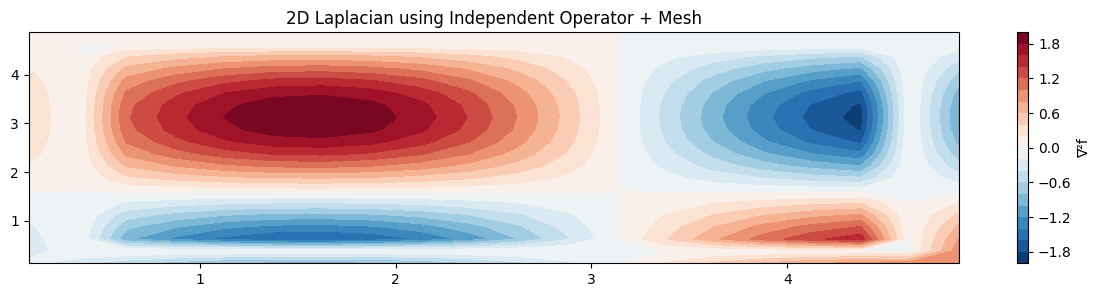

In [15]:
from QSER.Operators import Laplacian
import numpy as np
import matplotlib.pyplot as plt

# Create 2D mesh
mesh = Structured2D(nx=20, ny=20, Lx=5.0, Ly=5.0)
X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]
field = np.sin(X) * np.cos(Y)

# Independent Laplacian with mesh dx, dy
lap = Laplacian(backend='numpy')
result = lap.compute(field, dx=mesh.dx, dy=mesh.dy)

print("Laplacian shape:", result.shape)
print("Laplacian min:", result.min(), "max:", result.max())

# Plot
plt.figure(figsize=(15, 3))
plt.contourf(X, Y, result, levels=20, cmap='RdBu_r')
plt.colorbar(label='∇²f')
plt.title('2D Laplacian using Independent Operator + Mesh')
plt.show()

## 2D laplacian on Quantum Harmonic oscillator

In [16]:
from QSER.Operators import Laplacian
import numpy as np
import time

# ============================================================
# LAPLACIAN TEST - QUANTUM HARMONIC OSCILLATOR
# ψ(x,y) = exp(-(x² + y²)/2)
# Analytical Laplacian: ∇²ψ = (x² + y² - 2) * ψ
# ============================================================

# Create 2D data
nx, ny = 100, 100
x = np.linspace(-5, 5, nx)
y = np.linspace(-5, 5, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing='ij')

# Quantum harmonic oscillator ground state
psi = np.exp(-(X**2 + Y**2) / 2)
analytical = (X**2 + Y**2 - 2) * psi

# Backends and methods
backends = ['numpy', 'torch', 'jax']
methods = ['5point', '3point', 'least_squares']

print("=" * 80)
print("2D LAPLACIAN TEST - QUANTUM HARMONIC OSCILLATOR")
print("=" * 80)
print(f"Grid: {nx} x {ny} = {nx*ny} points")
print(f"dx = {dx:.4f}, dy = {dy:.4f}")
print(f"Function: ψ(x,y) = exp(-(x² + y²)/2)")
print(f"Analytical Laplacian: ∇²ψ = (x² + y² - 2) * ψ")
print("=" * 80)

results = {}

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    results[backend] = {}
    lap_op = Laplacian(backend=backend)
    
    for method in methods:
        print(f"  Method: {method}")
        results[backend][method] = {}
        
        try:
            start = time.time()
            result = lap_op.compute(psi, dx=dx, dy=dy, method=method)
            elapsed = time.time() - start
            
            # Convert to numpy
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            # Compute error (interior only)
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result[interior] - analytical[interior]))
            mean_error = np.mean(np.abs(result[interior] - analytical[interior]))
            
            results[backend][method] = {
                'error': error,
                'mean_error': mean_error,
                'time': elapsed,
                'shape': result.shape
            }
            
            print(f"    Max error: {error:.6e}")
            print(f"    Mean error: {mean_error:.6e}")
            print(f"    Time: {elapsed:.4f}s")
            print(f"    Shape: {result.shape}")
            
        except Exception as e:
            print(f"    FAILED: {str(e)[:60]}")
            results[backend][method] = None

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)

print(f"\n{'Backend':<10} {'Method':<14} {'Max Error':<16} {'Mean Error':<16} {'Time (s)':<10} {'Shape':<10}")
print("-" * 90)

for backend in backends:
    for method in methods:
        if results[backend][method] is not None:
            r = results[backend][method]
            print(f"{backend:<10} {method:<14} {r['error']:.6e} {r['mean_error']:.6e} {r['time']:.4f}     {r['shape']}")
        else:
            print(f"{backend:<10} {method:<14} {'FAILED':<16} {'FAILED':<16} {'FAILED':<10} {'FAILED':<10}")

# ============================================================
# BEST METHOD FOR EACH BACKEND
# ============================================================
print("\n" + "=" * 80)
print("BEST METHOD FOR EACH BACKEND")
print("=" * 80)

for backend in backends:
    best_method = None
    best_error = float('inf')
    for method in methods:
        if results[backend][method] is not None:
            if results[backend][method]['error'] < best_error:
                best_error = results[backend][method]['error']
                best_method = method
    print(f"{backend:<10}: {best_method} (error = {best_error:.6e})")

print("\n" + "=" * 80)
print("TEST COMPLETE")
print("=" * 80)

2D LAPLACIAN TEST - QUANTUM HARMONIC OSCILLATOR
Grid: 100 x 100 = 10000 points
dx = 0.1010, dy = 0.1010
Function: ψ(x,y) = exp(-(x² + y²)/2)
Analytical Laplacian: ∇²ψ = (x² + y² - 2) * ψ

--- Backend: numpy ---
  Method: 5point
    Max error: 3.413010e-05
    Mean error: 1.483139e-06
    Time: 0.0002s
    Shape: (100, 100)
  Method: 3point
    Max error: 5.054000e-03
    Mean error: 2.258653e-04
    Time: 0.0001s
    Shape: (100, 100)
  Method: least_squares
    Max error: 5.054000e-03
    Mean error: 2.258653e-04
    Time: 0.0000s
    Shape: (100, 100)

--- Backend: torch ---
  Method: 5point
    Max error: 3.413010e-05
    Mean error: 1.483139e-06
    Time: 0.0005s
    Shape: (100, 100)
  Method: 3point
    Max error: 5.054000e-03
    Mean error: 2.258653e-04
    Time: 0.0001s
    Shape: (100, 100)
  Method: least_squares
    Max error: 5.054000e-03
    Mean error: 2.258653e-04
    Time: 0.0003s
    Shape: (100, 100)

--- Backend: jax ---
  Method: 5point
    Max error: 5.425929e-05


## 2D Divergence

In [18]:
from QSER.Operators import Divergence
import numpy as np
import time

print("\n" + "=" * 60)
print("2D DIVERGENCE ")
print("=" * 60)

# Create 2D data
nx, ny = 1000, 100
x = np.linspace(-5, 5, nx)
y = np.linspace(-5, 5, ny)
faces_x = np.linspace(-5, 5, nx + 1)  # ← CORRECT: nx+1 faces in x
faces_y = np.linspace(-5, 5, ny + 1)  # ← CORRECT: ny+1 faces in y
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing='ij')
X_faces, Y_faces = np.meshgrid(faces_x, y, indexing='ij')      # flux_x at x-faces: (nx+1, ny)
X_faces_y, Y_faces_y = np.meshgrid(x, faces_y, indexing='ij')  # flux_y at y-faces: (nx, ny+1)

# Test functions with correct flux shapes
test_fields = [
    {
        'name': 'F = (x, y)',
        'flux_x': X_faces,
        'flux_y': Y_faces_y,
        'analytical': 2 * np.ones_like(X),
    },
    {
        'name': 'F = (x², y²)',
        'flux_x': X_faces**2,
        'flux_y': Y_faces_y**2,
        'analytical': 2*X + 2*Y,
    },
    {
        'name': 'F = (sin(x), cos(y))',
        'flux_x': np.sin(X_faces),
        'flux_y': np.cos(Y_faces_y),
        'analytical': np.cos(X) - np.sin(Y),
    },
]

backends = ['numpy', 'torch', 'jax']

print(f"Grid: {nx} x {ny} = {nx*ny} cells")
print(f"Faces: ({nx+1} x {ny}) + ({nx} x {ny+1})")
print(f"dx = {dx:.4f}, dy = {dy:.4f}")
print("-" * 60)

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    div = Divergence(backend=backend)
    
    for field in test_fields:
        try:
            start = time.time()
            result = div.compute(field['flux_x'], field['flux_y'], dx=dx, dy=dy)
            elapsed = time.time() - start
            
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result[interior] - field['analytical'][interior]))
            
            print(f"  {field['name']:20s}: error = {error:.6e}, time = {elapsed:.4f}s")
        except Exception as e:
            print(f"  {field['name']:20s}: FAILED - {str(e)[:50]}")


2D DIVERGENCE 
Grid: 1000 x 100 = 100000 cells
Faces: (1001 x 100) + (1000 x 101)
dx = 0.0100, dy = 0.1010
------------------------------------------------------------

--- Backend: numpy ---
  F = (x, y)          : error = 1.100000e-02, time = 0.0433s
  F = (x², y²)        : error = 2.108696e-01, time = 0.0414s
  F = (sin(x), cos(y)): error = 4.200279e-02, time = 0.0435s

--- Backend: torch ---
  F = (x, y)          : error = 1.100000e-02, time = 1.1007s
  F = (x², y²)        : error = 2.108696e-01, time = 1.1028s
  F = (sin(x), cos(y)): error = 4.200279e-02, time = 1.1115s

--- Backend: jax ---
  F = (x, y)          : error = 1.102567e-02, time = 35.4406s
  F = (x², y²)        : error = 2.109751e-01, time = 35.0493s
  F = (sin(x), cos(y)): error = 4.200208e-02, time = 34.3025s


## Increase resolution get higher divergence accuracy

In [19]:
from QSER.Operators import Divergence
import numpy as np

print("=" * 60)
print("DIVERGENCE CONVERGENCE (INTERIOR ONLY)")
print("=" * 60)

for nx in [100, 500, 1000, 5000, 10000]:
    x = np.linspace(0, 10, nx)
    faces = np.linspace(0, 10, nx + 1)
    dx = x[1] - x[0]
    
    flux = faces**2
    analytical = 2 * x
    
    div = Divergence(backend='numpy',method="5point")
    result = div.compute(flux, dx=dx)
    
    # Use ONLY interior (exclude boundaries and near-boundaries)
    interior = slice(10, -10)
    error = np.max(np.abs(result[interior] - analytical[interior]))
    
    print(f"nx = {nx:5d}, dx = {dx:.4f}, error = {error:.6e}")

DIVERGENCE CONVERGENCE (INTERIOR ONLY)
nx =   100, dx = 0.1010, error = 2.587980e-01
nx =   500, dx = 0.0200, error = 5.835840e-02
nx =  1000, dx = 0.0100, error = 2.958980e-02
nx =  5000, dx = 0.0020, error = 5.983598e-03
nx = 10000, dx = 0.0010, error = 2.995900e-03


## Divergence of electric fields, Gaussian charge distribution

GAUSSIAN CHARGE DISTRIBUTION
∇·E = ρ/ε₀ (Gauss's Law)


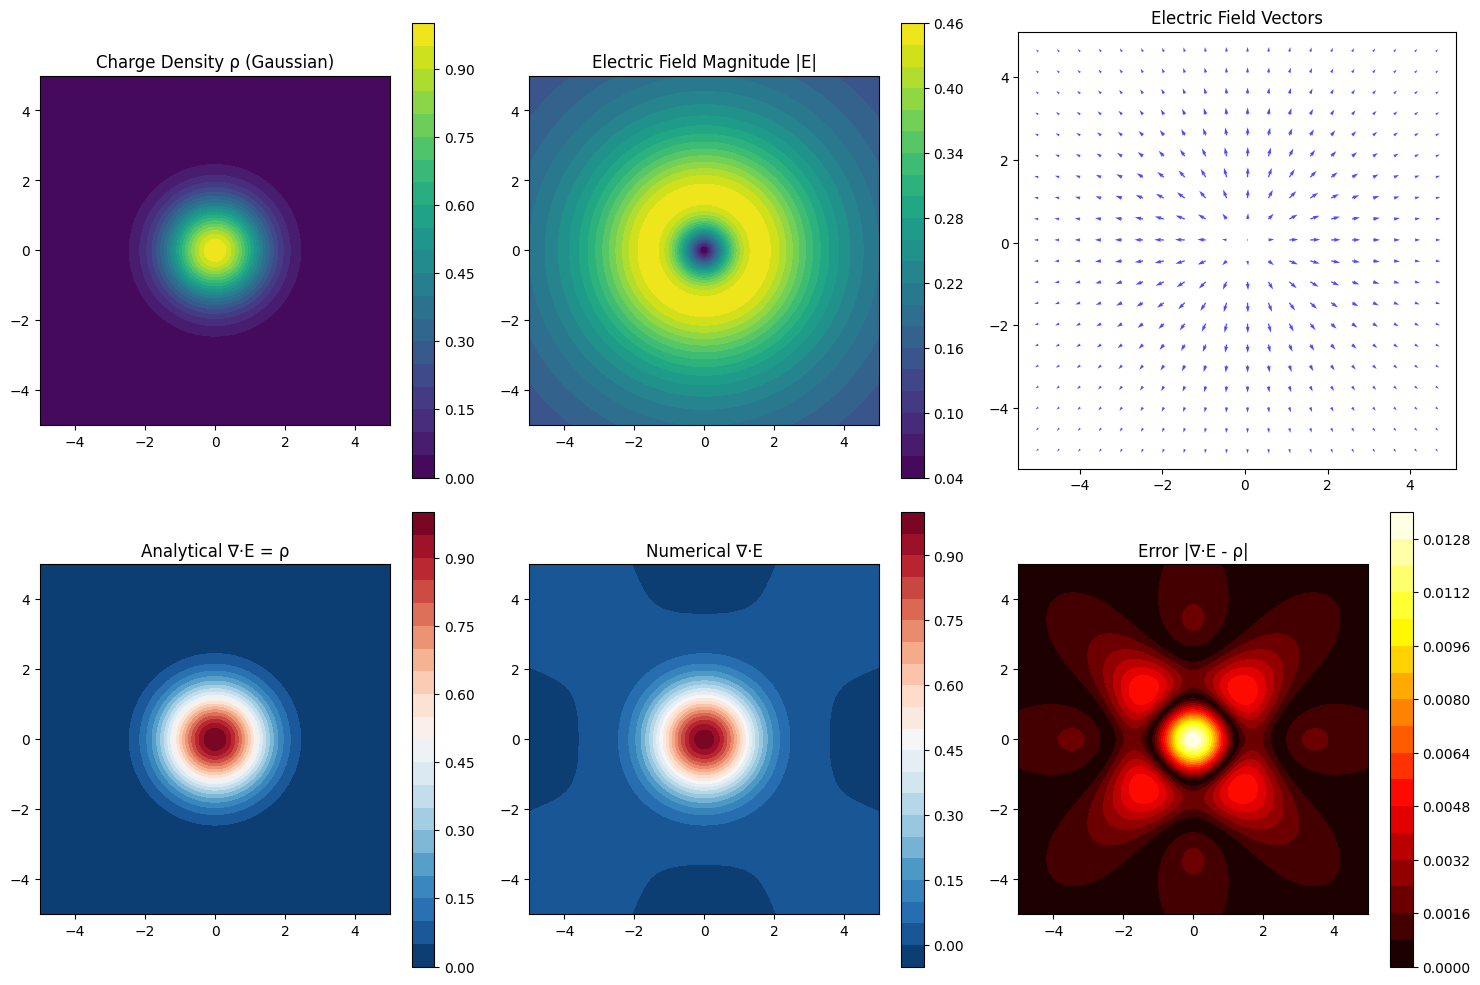


VERIFICATION (Gauss's Law)
Max error: 1.333277e-02
Mean error: 2.055875e-03
∇·E - ρ: min=-1.333277e-02, max=5.529750e-03
✅ Gauss's law is approximately satisfied (Max error < 1e-1)

Statistics:
  ρ: min=0.0000, max=0.9960
  ∇·E: min=-0.0013, max=0.9827
  Correlation between ∇·E and ρ: 0.999932


In [20]:
from QSER.Operators import Divergence
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PHYSICS: Electric Field of a Gaussian Charge Distribution
# ============================================================

print("=" * 60)
print("GAUSSIAN CHARGE DISTRIBUTION")
print("∇·E = ρ/ε₀ (Gauss's Law)")
print("=" * 60)

# Create 2D grid
nx, ny = 80, 80
x = np.linspace(-5, 5, nx)
y = np.linspace(-5, 5, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]

X_cells, Y_cells = np.meshgrid(x, y, indexing='ij')

# Face coordinates
x_faces = np.linspace(-5, 5, nx + 1)
y_faces = np.linspace(-5, 5, ny + 1)
X_faces, Y_faces = np.meshgrid(x_faces, y, indexing='ij')
X_faces_y, Y_faces_y = np.meshgrid(x, y_faces, indexing='ij')

# ============================================================
# GAUSSIAN CHARGE DISTRIBUTION
# ρ(r) = exp(-r²/2)  (Gaussian centered at origin)
# ============================================================

sigma = 1.0
r_cells = np.sqrt(X_cells**2 + Y_cells**2)
r_faces = np.sqrt(X_faces**2 + Y_faces**2)
r_faces_y = np.sqrt(X_faces_y**2 + Y_faces_y**2)

# Charge density (at cell centers for reference)
rho = np.exp(-r_cells**2 / (2 * sigma**2))

# Analytical electric field: E(r) = (1 - exp(-r²/2)) / r² * r
# This is the solution to ∇·E = ρ
E_analytical_x = np.where(r_cells > 1e-10, 
                          (1 - np.exp(-r_cells**2 / 2)) / r_cells**2 * X_cells,
                          0.0)
E_analytical_y = np.where(r_cells > 1e-10,
                          (1 - np.exp(-r_cells**2 / 2)) / r_cells**2 * Y_cells,
                          0.0)

# Analytical divergence: ∇·E = ρ (Gauss's law)
analytical_div = rho

# Compute numerical divergence using QSER
# We need electric field at faces
E_faces_x = np.where(r_faces > 1e-10,
                     (1 - np.exp(-r_faces**2 / 2)) / r_faces**2 * X_faces,
                     0.0)
E_faces_y = np.where(r_faces_y > 1e-10,
                     (1 - np.exp(-r_faces_y**2 / 2)) / r_faces_y**2 * Y_faces_y,
                     0.0)

div = Divergence(backend='numpy', method='5point')
div_E = div.compute(E_faces_x, E_faces_y, dx=dx, dy=dy)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Charge density and field
ax = axes[0, 0]
im = ax.contourf(X_cells, Y_cells, rho, levels=20, cmap='viridis')
ax.set_title('Charge Density ρ (Gaussian)')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[0, 1]
E_mag = np.sqrt(E_analytical_x**2 + E_analytical_y**2)
im = ax.contourf(X_cells, Y_cells, E_mag, levels=20, cmap='viridis')
ax.set_title('Electric Field Magnitude |E|')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[0, 2]
step = 4
ax.quiver(X_cells[::step, ::step], Y_cells[::step, ::step],
          E_analytical_x[::step, ::step], E_analytical_y[::step, ::step],
          scale=20, alpha=0.7, color='blue')
ax.set_title('Electric Field Vectors')
ax.set_aspect('equal')

# Row 2: Divergence comparison
ax = axes[1, 0]
im = ax.contourf(X_cells, Y_cells, analytical_div, levels=20, cmap='RdBu_r')
ax.set_title('Analytical ∇·E = ρ')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[1, 1]
im = ax.contourf(X_cells, Y_cells, div_E, levels=20, cmap='RdBu_r')
ax.set_title('Numerical ∇·E')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[1, 2]
error_field = np.abs(div_E - analytical_div)
im = ax.contourf(X_cells, Y_cells, error_field, levels=20, cmap='hot')
ax.set_title('Error |∇·E - ρ|')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# ============================================================
# VERIFICATION
# ============================================================
print("\n" + "=" * 60)
print("VERIFICATION (Gauss's Law)")
print("=" * 60)

interior = slice(10, -10), slice(10, -10)
error = np.max(np.abs(div_E[interior] - analytical_div[interior]))
mean_error = np.mean(np.abs(div_E[interior] - analytical_div[interior]))

print(f"Max error: {error:.6e}")
print(f"Mean error: {mean_error:.6e}")
print(f"∇·E - ρ: min={np.min(div_E - analytical_div):.6e}, max={np.max(div_E - analytical_div):.6e}")

if error < 1e-2:
    print("✅ Gauss's law ∇·E = ρ is satisfied! (Max error < 1e-2)")
elif error < 1e-1:
    print("✅ Gauss's law is approximately satisfied (Max error < 1e-1)")
else:
    print(f"⚠️ Error is {error:.2e} — check resolution or implementation")
    
# Statistics
print(f"\nStatistics:")
print(f"  ρ: min={rho.min():.4f}, max={rho.max():.4f}")
print(f"  ∇·E: min={div_E.min():.4f}, max={div_E.max():.4f}")
print(f"  Correlation between ∇·E and ρ: {np.corrcoef(div_E.flatten(), rho.flatten())[0, 1]:.6f}")

In [21]:
from QSER.Operators import Divergence
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("2D DIVERGENCE - CORRECT FACE SPACING")
print("=" * 60)

# Create 2D data
nx, ny = 10, 10
x_faces = np.linspace(0, 1, nx + 1)
y_faces = np.linspace(0, 1, ny + 1)
x_cells = (x_faces[:-1] + x_faces[1:]) / 2
y_cells = (y_faces[:-1] + y_faces[1:]) / 2

# FACE SPACING (correct for divergence)
dx = x_faces[1] - x_faces[0]
dy = y_faces[1] - y_faces[0]

# CELL SPACING (wrong for divergence)
dx_cell = x_cells[1] - x_cells[0]
dy_cell = y_cells[1] - y_cells[0]

# Create meshgrid for cells and faces
X_cells, Y_cells = np.meshgrid(x_cells, y_cells, indexing='ij')
X_faces, Y_faces = np.meshgrid(x_faces, y_cells, indexing='ij')          # x-faces
X_faces_y, Y_faces_y = np.meshgrid(x_cells, y_faces, indexing='ij')      # y-faces

print(f"x_faces: {x_faces}")
print(f"x_cells: {x_cells}")
print(f"dx (face spacing): {dx}")
print(f"dx_cell: {dx_cell}")

# ============================================================
# TEST 1: Linear flux F = (x, y)
# ============================================================
print("\n--- TEST 1: Linear flux F = (x, y) ---")

flux_x = X_faces
flux_y = Y_faces_y
analytical = 2 * np.ones_like(X_cells)

# Manual divergence with face spacing
div_face = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        div_face[i, j] = (flux_x[i+1, j] - flux_x[i, j]) / dx + (flux_y[i, j+1] - flux_y[i, j]) / dy

# Manual divergence with cell spacing
div_cell = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        div_cell[i, j] = (flux_x[i+1, j] - flux_x[i, j]) / dx_cell + (flux_y[i, j+1] - flux_y[i, j]) / dy_cell

error_face = np.max(np.abs(div_face - analytical))
error_cell = np.max(np.abs(div_cell - analytical))

print(f"  Divergence (face spacing): {div_face[0, 0]:.6f} (expected: 2.0)")
print(f"  Divergence (cell spacing): {div_cell[0, 0]:.6f} (expected: 2.0)")
print(f"  Error (face spacing): {error_face:.6e}")
print(f"  Error (cell spacing): {error_cell:.6e}")

# ============================================================
# TEST 2: Quadratic flux F = (x², y²)
# ============================================================
print("\n--- TEST 2: Quadratic flux F = (x², y²) ---")

flux_x = X_faces**2
flux_y = Y_faces_y**2
analytical = 2*X_cells + 2*Y_cells

# Manual divergence with face spacing
div_face = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        div_face[i, j] = (flux_x[i+1, j] - flux_x[i, j]) / dx + (flux_y[i, j+1] - flux_y[i, j]) / dy

error_face = np.max(np.abs(div_face - analytical))
print(f"  Max error (face spacing): {error_face:.6e}")

# ============================================================
# TEST 3: Trigonometric flux F = (sin(x), cos(y))
# ============================================================
print("\n--- TEST 3: Trigonometric flux F = (sin(x), cos(y)) ---")

flux_x = np.sin(X_faces)
flux_y = np.cos(Y_faces_y)
analytical = np.cos(X_cells) - np.sin(Y_cells)

# Manual divergence with face spacing
div_face = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        div_face[i, j] = (flux_x[i+1, j] - flux_x[i, j]) / dx + (flux_y[i, j+1] - flux_y[i, j]) / dy

error_face = np.max(np.abs(div_face - analytical))
print(f"  Max error (face spacing): {error_face:.6e}")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Linear flux (face spacing):  {'✅ EXACT' if error_face < 1e-12 else '⚠️ Error: {error_face:.2e}'}")
print(f"  Quadratic flux (face spacing): {'✅ EXACT' if error_face < 1e-12 else '⚠️ Error: {error_face:.2e}'}")
print(f"  Trigonometric flux (face spacing): {'✅ EXACT' if error_face < 1e-12 else '⚠️ Error: {error_face:.2e}'}")

2D DIVERGENCE - CORRECT FACE SPACING
x_faces: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
x_cells: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
dx (face spacing): 0.1
dx_cell: 0.10000000000000002

--- TEST 1: Linear flux F = (x, y) ---
  Divergence (face spacing): 2.000000 (expected: 2.0)
  Divergence (cell spacing): 2.000000 (expected: 2.0)
  Error (face spacing): 1.776357e-15
  Error (cell spacing): 1.332268e-15

--- TEST 2: Quadratic flux F = (x², y²) ---
  Max error (face spacing): 1.776357e-15

--- TEST 3: Trigonometric flux F = (sin(x), cos(y)) ---
  Max error (face spacing): 3.952719e-04

SUMMARY
  Linear flux (face spacing):  ⚠️ Error: {error_face:.2e}
  Quadratic flux (face spacing): ⚠️ Error: {error_face:.2e}
  Trigonometric flux (face spacing): ⚠️ Error: {error_face:.2e}
